# Geração automática de laudo interpretativo de glaucoma a partir do relatório Zeiss Cirrus

**Autor:** Rafael Tardelli · **Professora:** Manoela Kohler
MBA PUC-Rio em Generative AI & LLM · disciplina PAI — Processamento e Análise de Imagens

---

### Onde está cada item pedido

| item | seção |
|---|---|
| Descrição clara do problema abordado | **§2** |
| Descrição da base de dados utilizada | **§3** |
| Metodologia adotada | **§4** (implementada nas §6–§10) |
| Relato dos experimentos realizados | **§11** |
| Análise dos resultados e conclusões | **§15** (validação em **§12**) |

A **§1** é uma introdução ao exame para quem não é da área, e não substitui nenhum dos itens
acima.

---

O aparelho de OCT entrega uma página cheia de números e cores. O que ela **não** contém é o
parágrafo que o médico escreve depois — a interpretação. Este trabalho produz esse parágrafo
a partir da página, por processamento de imagem, sem nenhuma rede neural.

O que torna isso possível é que **no relatório Zeiss a cor já é o diagnóstico**: cada medida
é comparada contra um banco normativo e o resultado é codificado como cor. E a legenda dessa
codificação está impressa na própria página, o que permite ao classificador se calibrar a
partir da imagem que ele analisa.

### Entrada e saída

| | |
|---|---|
| **Entrada** | um PDF `ONH and RNFL OU Analysis: Optic Disc Cube 200x200` do Cirrus HD-OCT |
| **Saída** | um laudo interpretativo em texto, com cada frase rastreável até o campo e a cor que a produziram |

### O que o notebook faz, em ordem

| § | Etapa | |
|---|---|---|
| 6 | Anonimiza o PDF e mapeia sua estrutura | 22 imagens embutidas localizadas por tamanho e posição |
| 7 | Calibra as cores pela legenda impressa | 5 amostras extraídas da própria página |
| 8 | Lê a tabela por casamento de padrões | valor **e** cor de 13 células |
| 9 | Lê os diagramas de quadrantes e horários | 32 setores, com mapeamento anatômico OD/OE |
| 10 | Mede a escavação horizontal no tomograma | o único número do laudo que o aparelho não imprime |
| 11 | Relata os experimentos | as três decisões de projeto, medidas lado a lado |
| 12 | Valida | 12 checagens aritméticas internas à página |
| 13 | Consolida os achados | JSON com valor, cor, classe normativa e origem |
| 14 | Aplica as regras e escreve o laudo | cada frase carrega a sua procedência |

### Anonimização

O relatório é de uma paciente real. **Nome e identificador são removidos do PDF** — do texto,
não só cobertos — antes de qualquer processamento. O laudo gerado identifica a paciente por
um carimbo de tempo da execução e o médico solicitante por um nome fictício fixo.

## 1. Entendendo o exame (para quem não é da área)

### A retina é um bolo de camadas

A retina tem cerca de **0,3 mm** — mais fina que um cartão de crédito — e dentro dessa
espessura existem umas dez camadas empilhadas, cada uma com uma função. Olhando o olho por
fora, como faz o oftalmologista com a lanterna, vê-se apenas a cobertura do bolo. Para saber
se uma camada específica está mais fina do que deveria, é preciso cortar uma fatia e olhar o
empilhamento de lado.

### O OCT corta sem cortar

O OCT — *tomografia de coerência óptica* — faz exatamente esse corte, com luz em vez de faca.
É a mesma ideia do ultrassom obstétrico, trocando som por luz infravermelha: o aparelho
dispara um feixe e mede o tempo que o reflexo leva para voltar de cada profundidade. Tempos
diferentes, profundidades diferentes; juntando tudo, monta-se a imagem da fatia.

Duas palavras aparecem o tempo todo:

- **B-scan** — a foto da fatia. A retina vista de perfil, com as camadas empilhadas.
- **En-face** — a foto do bolo por cima. O fundo do olho como se vê numa retinografia.

### Glaucoma: o cabelo e o ralo

As **células ganglionares** são as que levam o sinal da visão do olho para o cérebro. Os fios
dessas células — os axônios — convergem todos para um mesmo ponto na retina, o **disco
óptico**, como cabelo penteado na direção de um ralo. Esse feixe reunido é o nervo óptico.

O glaucoma mata essas células, devagar e sem sintoma até tarde. E deixa dois rastros
mensuráveis:

1. **A camada de fibras fica mais fina.** Menos fios passando, camada mais fina. Essa camada
   é a **RNFL** (*Retinal Nerve Fiber Layer*), e é ela que o exame mede em micrometros ao
   redor do disco.
2. **A cratera do disco cresce.** No centro do disco há uma depressão natural, a **escavação**
   (*cup*). Conforme as fibras morrem, a borda de tecido em volta — a **rima** — afina e a
   cratera se alarga. A razão entre o diâmetro da cratera e o do disco é a **relação
   escavação/disco (C/D)**. Uma cratera que ocupa 70% do disco é diferente de uma que ocupa
   30%.

Uma imagem que ajuda: pense num **gramado com um ralo no meio**. O glaucoma é a grama morrendo
em manchas. Dá para perceber de dois jeitos — medindo a altura da grama em volta (RNFL) ou
vendo o buraco em torno do ralo ficar maior (escavação). O exame faz os dois.

### Por que este exame, e não outro

O Cirrus tem vários protocolos. Dois interessam ao glaucoma, e a diferença entre eles é a
mesma do gramado:

- **Optic Disc Cube 200x200** — varre a região do **disco**. Mede os *fios* (a RNFL em volta
  do ralo) e a *cratera* (a escavação). É o exame usado aqui.
- **Macular Cube / Ganglion Cell** — varre a **mácula**, o centro da visão. Mede os *corpos*
  das células ganglionares, não os fios. É complementar, e cobre o que falta a este trabalho.

Um terceiro, o **HD 5 Line Raster**, é só um corte de alta definição para inspeção visual —
não traz medida normativa nenhuma.

### E as cores?

Cada medida que o aparelho tira é comparada com um banco de dados de pessoas normais da mesma
faixa etária, e o resultado vira **cor**:

| cor | significado |
|---|---|
| cinza | sem comparação normativa disponível |
| branco | acima do percentil 95 (mais espesso que o esperado) |
| verde | entre os percentis 5 e 95 — **normal** |
| amarelo | entre os percentis 1 e 5 — **limítrofe** |
| vermelho | abaixo do percentil 1 — **fora dos limites** |

É o mesmo raciocínio da curva de crescimento do pediatra: o número sozinho não diz nada, o
que importa é onde ele cai na distribuição da população.

**Esse é o ponto central deste trabalho.** A classificação normativa — a parte difícil, que
exige o banco de dados — já foi feita pelo aparelho e está codificada na cor de cada célula e
de cada setor. Ler a cor é ler o diagnóstico normativo. E como a legenda está impressa na
página, o classificador não precisa de nenhum valor RGB fixo no código: ele se calibra a
partir da imagem que está analisando.

## 2. Descrição do problema

### O que se quer produzir

O objetivo é um laudo interpretativo, no formato que um oftalmologista escreveria:

> Espessura média da RNFL OD 60 µm, OE 52 µm, ambas abaixo dos limites da normalidade.
> Escavação vertical OD 0,70, OE 0,75. O conjunto configura sinais estruturais sugestivos de
> neuropatia óptica glaucomatosa bilateral, mais acentuada em OE. Recomenda-se correlação com
> a avaliação clínica, a pressão intraocular e a perimetria.

### Por que isso não é "refazer o que o exame já mostra"

É uma objeção legítima e vale respondê-la de frente. O aparelho mede melhor do que qualquer
análise da página conseguiria: ele trabalha sobre o volume 3D bruto, não sobre uma figura
renderizada. Tentar remedir a espessura a partir da imagem impressa seria reproduzir, com
menos precisão, algo que já está pronto.

Mas o laudo **não está na página**. A página tem números e cores; o parágrafo interpretativo
é escrito depois, por uma pessoa. É esse passo — o que os achados significam em conjunto —
que este trabalho automatiza. A saída não existe no arquivo de entrada.

### Por que é possível fazer isso por processamento de imagem

Porque a informação necessária está toda codificada visualmente, de forma regular:

- **A cor carrega a classificação normativa** — e a legenda que a define está na página.
- **A fonte é fixa.** O Zeiss renderiza os números sempre com o mesmo desenho, sem variação de
  antialiasing. Casamento de padrões funciona; nem é preciso OCR genérico.
- **A geometria é fixa.** Tabela em grade, diagramas circulares com setores de ângulo
  conhecido, tomogramas com a membrana limitante interna já traçada pelo aparelho.

### O que o trabalho acrescenta

Além de reunir e interpretar o que está impresso, há um número que **o equipamento não
fornece**: a **escavação horizontal**. O Cirrus imprime a vertical e a média, não a
horizontal — e o laudo-modelo pede as duas. A §10 mede essa razão geometricamente sobre o
tomograma, ancorando-se no valor vertical impresso.

## 3. Base de dados

Um único exame, em PDF: `ONH and RNFL OU Analysis: Optic Disc Cube 200x200`, Cirrus HD-OCT,
software 7.0.3.19, página US Letter (612×792 pt), de uma paciente real.

### Por que PDF e não a captura de tela

O PDF guarda as figuras como **objetos embutidos em resolução nativa**, cada um com a sua
posição na página. Os tomogramas têm 301×166 px no PDF contra 127×82 numa captura de tela da
mesma página — 2,4× mais detalhe em cada dimensão. E os objetos vêm separados e localizados,
o que dispensa detectá-los na página.

Um cuidado importante: **não se deve rasterizar a página a 300 dpi** esperando ganhar detalhe.
A tabela é um bitmap de 274×164; rasterizar a página inteira só interpolaria esse bitmap. A
imagem embutida é o teto de resolução disponível.

### O que a camada de texto tem — e o que não tem

Inspecionando o PDF com `pymupdf`: existe camada de texto, mas ela cobre **apenas o
cabeçalho** — datas, técnico, *Signal Strength*, títulos de seção, rodapé. **Os números
clínicos não são texto.** A tabela de medidas é um bitmap; os diagramas de quadrante e horário
são bitmaps **com os números embutidos nos pixels**; a legenda de cores é outro bitmap
isolado.

Duas consequências:

1. Não há gabarito gratuito para as medidas. A validação tem de vir de outro lugar — e vem, da
   consistência aritmética interna da página (§12).
2. Ler os números **pela imagem** não é uma escolha estilística: é a única via. O que também é
   conveniente, porque é exatamente o que a disciplina avalia. Mesmo onde a camada de texto
   serviria, ler dela seria trocar análise de imagem por *parsing* de PDF.

### Anonimização — restrição vinculante

| Campo | Regra |
|---|---|
| Nome da paciente | **removido do PDF**, nunca extraído, nunca emitido |
| Identificador | **removido do PDF**, nunca extraído, nunca emitido |
| Data de nascimento | preservada no arquivo, **nunca emitida** — serve só para derivar a idade |
| Médico solicitante | fixo `Dr. R2D2`; não vem do exame |
| Identificação no laudo | `Paciente <carimbo de tempo da execução>` |

O identificador muda a cada execução, então o mesmo exame gera identificações diferentes. É
intencional — dificulta a reidentificação — ao custo da rastreabilidade.

O PDF original, com os dados da paciente, fica em `imagens_originais/`, que está no
`.gitignore`. O que é versionado é o PDF anonimizado em `imagens/`.

## 4. Metodologia

O pipeline tem oito etapas. Nenhuma usa aprendizado de máquina.

| § | Etapa | Técnica |
|---|---|---|
| 6 | Anonimização e mapeamento | remoção de texto no PDF; identificação das imagens embutidas por tamanho e posição |
| 7 | Calibração cromática | projeções para achar as amostras da legenda; mediana por amostra |
| 8 | Leitura da tabela | projeções para a grade; segmentação de caracteres por projeção vertical; casamento exato de bitmaps |
| 9 | Leitura dos setores | centro e raio por saturação; agrupamento de dígitos; coordenadas polares; amostragem de cor por ângulo |
| 10 | Escavação horizontal | segmentação do contorno por chave de cor; detecção dos marcadores; plano de referência; razão de anisotropia |
| 11 | Relato dos experimentos | comparação medida entre as alternativas testadas |
| 12 | Validação | restrições aritméticas internas à página |
| 13 | Consolidação | JSON de achados com procedência |
| 14 | Geração do laudo | regras determinísticas sobre o JSON |

### Duas decisões que estruturam o trabalho

**A cor é classificada contra a legenda da própria página, não contra constantes.** Isso
protege contra variação de compressão JPEG entre exemplares e torna o método transferível a
outros relatórios do mesmo equipamento sem recalibração manual.

**A leitura numérica é casamento de padrões, não OCR.** A fonte do Zeiss é fixa e o
antialiasing é determinístico nessa escala, o que faz os bitmaps de um mesmo caractere serem
**byte a byte idênticos**. O casamento de padrões degenera em busca exata numa tabela — sem
limiar de correlação, sem falso positivo possível. A §8 mostra a medição que sustenta isso.

### Por que não uma rede neural

Além de a interpretação ser um problema de regras e não de percepção, houve uma tentativa
anterior neste projeto de usar um classificador pré-treinado de OCT (RETFound). O *checkpoint*
público avaliado devolvia a mesma classe para qualquer entrada, inclusive ruído branco — a
cabeça de classificação nunca havia sido treinada. O episódio está resumido na §15. Aqui ele
serve como justificativa: um modelo verificado e reprovado é motivo suficiente para preferir
um método determinístico e auditável.

## 5. Setup e dependências

In [1]:
# Bibliotecas e constantes de todo o pipeline. Nao ha nada de aprendizado de maquina aqui:
# pymupdf le o PDF, numpy/scipy fazem o processamento, pandas/matplotlib mostram o resultado.
from __future__ import annotations

import io, json, shutil, datetime as dt
from pathlib import Path

import numpy as np
import pandas as pd
import pymupdf
import matplotlib.pyplot as plt
from PIL import Image
from scipy import ndimage as ndi

pd.set_option("display.max_colwidth", 90)
plt.rcParams.update({"figure.dpi": 110, "font.size": 8, "axes.grid": False})

# ---- caminhos -------------------------------------------------------------
ORIGINAL = Path("imagens_originais/optic_disc_cube.pdf")   # com dados da paciente, fora do git
PDF      = Path("imagens/optic_disc_cube_anon.pdf")        # anonimizado, versionado

# ---- constantes do pipeline ----------------------------------------------
TINTA     = 110     # V abaixo disto e tinta preta (texto, grade, contornos)
SAT       = 50      # (max-min) acima disto e pixel colorido
BORDA     = 90      # V abaixo disto e borda preta forte (legenda)
DEPTH_UM  = 2000.0  # profundidade axial do tomograma do Cirrus, em micrometros
PLANO_UM  = 100.0   # plano de referencia da escavacao, abaixo do plano do disco
ROTULOS   = ("Name:", "ID:")   # campos removidos do PDF
VAO       = 20.0    # separacao (pt) entre blocos de texto no cabecalho
MEDICO    = "Dr. R2D2"

print(f"pymupdf {pymupdf.__version__} · numpy {np.__version__} · pandas {pd.__version__}")

pymupdf 1.28.2 · numpy 2.4.6 · pandas 3.0.3


## 6. Anonimização do PDF e mapeamento da estrutura

### 6.1 Remover, não cobrir

Desenhar um retângulo preto sobre um texto num PDF não apaga o texto — ele continua na camada
de texto, selecionável e extraível. A anonimização aqui usa `add_redact_annot` +
`apply_redactions` do PyMuPDF, que **removem os glifos** e queimam a tarja.

As caixas são **localizadas por detecção**, não por coordenadas fixas: para cada rótulo
(`Name:`, `ID:`), a função pega as palavras à direita dele na mesma faixa vertical e corta o
primeiro bloco contíguo — o valor — parando no vão que o separa da coluna seguinte. É o mesmo
critério de "blocos separados por vão" que se usaria numa imagem, aplicado às coordenadas das
palavras.

Duas garantias verificadas na saída:

- `apply_redactions(images=PDF_REDACT_IMAGE_NONE)` deixa as imagens embutidas **byte a byte
  intactas**. Isso não é preciosismo: recompressão de qualquer tipo altera pixels e
  desestabiliza medições que dependem de contornos de 1 px e de bitmaps casados por igualdade
  exata.
- Os metadados do documento são zerados.

Se o original não estiver presente — o caso de quem clonou o repositório —, a célula apenas
confere que o PDF versionado já está limpo.

In [2]:
def anonimizar(src: Path, dst: Path) -> list[dict]:
    """Remove nome e identificador da camada de texto e queima a tarja. Imagens intactas."""
    doc = pymupdf.open(src); pag = doc[0]
    # Cada palavra do PDF vem com a sua caixa. Achamos o rotulo ('Name:') e pegamos
    # o que esta a direita dele, na mesma altura.
    palavras = pag.get_text("words")          # (x0, y0, x1, y1, texto, bloco, linha, n)
    caixas = []
    for rot in ROTULOS:
        alvo = [w for w in palavras if w[4] == rot]
        if not alvo: continue
        # yc = meio da linha do rotulo; serve para achar as palavras da mesma linha.
        L = alvo[0]; yc = (L[1] + L[3]) / 2
        direita = sorted([w for w in palavras if w[1] <= yc <= w[3] and w[0] > L[2]],
                         key=lambda w: w[0])
        bloco = [direita[0]]                   # primeiro bloco contiguo = o valor
        for w in direita[1:]:
            if w[0] - bloco[-1][2] < VAO: bloco.append(w)
            else: break
        # Caixa que cobre o valor inteiro, com 2 pt de folga.
        r = pymupdf.Rect(bloco[0][0] - 2, min(b[1] for b in bloco) - 1,
                         bloco[-1][2] + 2, max(b[3] for b in bloco) + 1)
        pag.add_redact_annot(r, fill=(0, 0, 0))
        caixas.append(dict(campo=rot.rstrip(":"), rect=tuple(round(v, 1) for v in r),
                           palavras=len(bloco)))
    pag.apply_redactions(images=pymupdf.PDF_REDACT_IMAGE_NONE)   # nao toca nas imagens
    # Os metadados tambem podem guardar o nome; zeramos.
    doc.set_metadata({}); doc.del_xml_metadata()
    doc.save(dst, garbage=4, deflate=True, clean=True)
    return caixas

if ORIGINAL.exists():
    caixas = anonimizar(ORIGINAL, PDF)
    display(pd.DataFrame(caixas))
else:
    print(f"{ORIGINAL} ausente (esperado fora da máquina do autor) — usando {PDF}")

# --- verificacao: o PDF versionado nao pode conter identificacao ---
# Conferencia: nomes proprios no relatorio Zeiss vem em CAIXA ALTA. Se sobrou alguma
# linha assim, a remocao falhou.
texto = pymupdf.open(PDF)[0].get_text()
ident = [l for l in texto.splitlines() if any(c.isalpha() for c in l) and l.isupper()
         and len(l) > 8]
print("linhas em caixa alta remanescentes:", ident or "nenhuma")
for campo in ("DOB:", "Signal Strength:", "Exam Date:"):
    print(f"  {campo:<18} preservado: {campo in texto}")

,campo,rect,palavras
0,Name,"(125.4, 40.1, 259.0, 51.3)",3
1,ID,"(125.4, 60.3, 179.9, 71.5)",1


linhas em caixa alta remanescentes: nenhuma
  DOB:               preservado: True
  Signal Strength:   preservado: True
  Exam Date:         preservado: True


### 6.2 O que há dentro do PDF

Cada figura da página é um objeto embutido com tamanho próprio e posição conhecida. Isso
dispensa qualquer detecção de painel na página renderizada: basta identificar cada objeto pela
combinação **(largura, altura, posição)**, que é fixa para este layout de relatório.

O cabeçalho tem duas geometrias diferentes, e `cabecalho()` trata as duas: os campos da
paciente (`DOB`, `Gender`) ficam numa coluna logo à direita do rótulo, enquanto os campos por
olho (`Exam Date`, `Signal Strength`) estão alinhados sob os títulos `OD` e `OS`, separados por
um vão maior. Ancorar nesses títulos é o que faz os dois casos funcionarem.

A data de nascimento é **mascarada na saída desta célula**. Ela permanece no arquivo porque o
pipeline precisa dela para calcular a idade, mas nunca é emitida.

In [3]:
def abrir(pdf: Path):
    """Devolve a pagina e as imagens embutidas em resolucao nativa, com seus bbox."""
    doc = pymupdf.open(pdf); pag = doc[0]; imgs = {}
    # extract_image devolve os bytes originais da figura; get_image_rects, onde ela
    # aparece na pagina. Nada e re-comprimido.
    for item in pag.get_images(full=True):
        xref = item[0]; info = doc.extract_image(xref)
        r = pag.get_image_rects(xref)[0]
        arr = np.asarray(Image.open(io.BytesIO(info["image"])).convert("RGB")).astype(int)
        imgs[xref] = dict(img=arr, rect=(r.x0, r.y0, r.x1, r.y1), w=arr.shape[1], h=arr.shape[0])
    return pag, imgs

def por_papel(imgs: dict) -> dict:
    """Identifica cada imagem embutida por (largura, altura) e posicao na pagina."""
    # Cada figura e identificada pelo par (largura, altura) e, quando ha varias do mesmo
    # tamanho, pelo canto onde ela esta. O layout do relatorio e fixo.
    def achar(w, h, x=None, y=None):
        c = [k for k, v in imgs.items() if (v["w"], v["h"]) == (w, h)]
        if x: c = [k for k in c if x[0] <= imgs[k]["rect"][0] <= x[1]]
        if y: c = [k for k in c if y[0] <= imgs[k]["rect"][1] <= y[1]]
        return c
    return dict(
        tabela  = achar(274, 164)[0],
        legenda = achar(150, 65)[0],
        quad = {"OD": achar(116, 116, x=(200, 260), y=(500, 560))[0],
                "OS": achar(116, 116, x=(340, 400), y=(500, 560))[0]},
        hora = {"OD": achar(116, 116, x=(200, 260), y=(590, 650))[0],
                "OS": achar(116, 116, x=(340, 400), y=(590, 650))[0]},
        tomo = {("OD", "vertical"):   achar(301, 166, x=(80, 120), y=(505, 525))[0],
                ("OD", "horizontal"): achar(301, 166, x=(80, 120), y=(415, 430))[0],
                ("OS", "vertical"):   achar(301, 166, x=(440, 470), y=(505, 525))[0],
                ("OS", "horizontal"): achar(301, 166, x=(440, 470), y=(415, 430))[0]})

def cabecalho(pag) -> dict:
    """Le o cabecalho na camada de texto. Nome e identificador ja nao existem no arquivo.

    O cabecalho tem duas geometrias: campos do paciente (uma coluna, logo a direita do
    rotulo) e campos por olho, alinhados sob os titulos OD e OS.
    """
    ws = pag.get_text("words")
    # Os titulos OD e OS do alto da pagina dao a coluna de cada olho.
    col = {w[4]: w[0] for w in ws if w[4] in ("OD", "OS") and w[1] < 60}   # ancoras
    out = {}
    for rotulo, por_olho in [("DOB", False), ("Gender", False),
                             ("Exam Date", True), ("Signal Strength", True)]:
        marca = rotulo.split()[-1] + ":"          # 'Date:' distingue de 'Exam Time:'
        alvo = [w for w in ws if w[4] == marca]
        if not alvo: continue
        L = alvo[0]; yc = (L[1] + L[3]) / 2
        direita = sorted([w for w in ws if w[1] <= yc <= w[3] and w[0] > L[2] + 2],
                         key=lambda w: w[0])
        # Campo por olho: pega a palavra alinhada com a coluna OD e com a coluna OS.
        if por_olho:
            out[rotulo] = [next(w[4] for w in direita if abs(w[0] - col[o]) < 6)
                           for o in ("OD", "OS")]
        else:
            # Campo do paciente: uma coluna so, ate o primeiro vao grande.
            bloco = [direita[0]]                  # primeiro bloco contiguo = o valor
            for w in direita[1:]:
                if w[0] - bloco[-1][2] < VAO: bloco.append(w)
                else: break
            out[rotulo] = [w[4] for w in bloco]
    return out

pag, IMGS = abrir(PDF)
PAPEL = por_papel(IMGS)
CAB   = cabecalho(pag)

# Inventario do que o pipeline vai usar.
inv = pd.DataFrame([dict(xref=k, papel=nome, largura=IMGS[k]["w"], altura=IMGS[k]["h"],
                         x=round(IMGS[k]["rect"][0]), y=round(IMGS[k]["rect"][1]))
                    for nome, k in
                    [("tabela", PAPEL["tabela"]), ("legenda", PAPEL["legenda"])] +
                    [(f"quadrantes {o}", v) for o, v in PAPEL["quad"].items()] +
                    [(f"horários {o}", v)   for o, v in PAPEL["hora"].items()] +
                    [(f"tomograma {o} {e}", v) for (o, e), v in PAPEL["tomo"].items()]])
print(f"{len(IMGS)} imagens embutidas no PDF; {len(inv)} usadas pelo pipeline\n")
display(inv)
# DOB e mascarada aqui: ela fica no arquivo (o pipeline precisa dela) mas nunca e emitida
visivel = {k: ("••/••/•••• (usada só para derivar a idade)" if k == "DOB" else " ".join(v))
           for k, v in CAB.items()}
print("\ncabeçalho (camada de texto):", visivel)

22 imagens embutidas no PDF; 10 usadas pelo pipeline



,xref,papel,largura,altura,x,y
0,20,tabela,274,164,224,145
1,21,legenda,150,65,292,515
2,4,quadrantes OD,116,116,217,518
3,5,quadrantes OS,116,116,357,518
4,3,horários OD,116,116,217,604
5,2,horários OS,116,116,357,604
6,11,tomograma OD vertical,301,166,89,513
7,13,tomograma OD horizontal,301,166,89,421
8,16,tomograma OS vertical,301,166,449,513
9,17,tomograma OS horizontal,301,166,449,421



cabeçalho (camada de texto): {'DOB': '••/••/•••• (usada só para derivar a idade)', 'Gender': 'Female', 'Exam Date': '8/5/2026 8/5/2026', 'Signal Strength': '6/10 5/10'}


## 7. Calibração cromática pela legenda impressa

A legenda "Diversified: Distribution of Normals" é um bitmap isolado de 150×65 px com cinco
amostras lado a lado, separadas por bordas pretas, e os percentis 95%, 5% e 1% escritos
embaixo. Ela define, **na própria página**, o que cada cor significa.

O procedimento é uma dupla projeção: a faixa das amostras é a região entre as duas linhas
horizontais escuras; dentro dela, as colunas majoritariamente pretas são as bordas verticais.
A cor de cada amostra é a mediana do seu interior — mediana, e não média, para não ser puxada
por pixels de borda que sobrevivam ao recorte.

Classificar passa então a ser vizinho mais próximo em RGB contra essas cinco referências.
Nenhum valor de cor fica escrito no código.

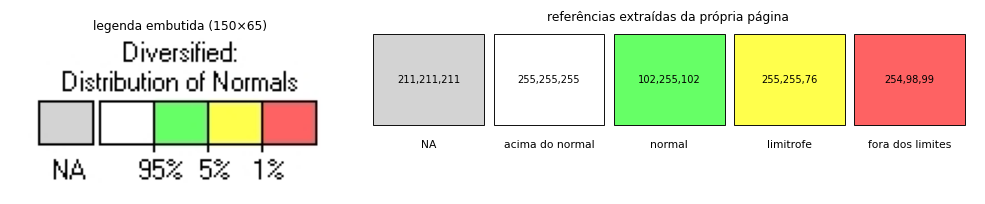

In [4]:
# As 5 classes normativas do Zeiss, na ordem em que aparecem na legenda impressa
# (esquerda para a direita). PT so traduz para exibicao.
CLASSES = ["NA", "acima do normal", "normal", "limitrofe", "fora dos limites"]
PT = {"NA": "sem comparação normativa", "acima do normal": "acima do normal",
      "normal": "normal", "limitrofe": "limítrofe", "fora dos limites": "fora dos limites"}

def calibrar(leg: np.ndarray) -> dict:
    """Extrai as 5 cores de referencia da legenda impressa na pagina."""
    # A legenda e uma fileira de amostras com bordas pretas. Duas projecoes acham a grade:
    # as linhas escuras horizontais delimitam a faixa, as verticais separam as amostras.
    esc = leg.max(axis=2) < BORDA
    lin = [y for y in range(leg.shape[0]) if esc[y].mean() > 0.5]   # bordas horizontais
    banda = leg[lin[0] + 1:lin[-1]]
    e = banda.max(axis=2) < BORDA
    sep = [x for x in range(leg.shape[1]) if e[:, x].mean() > 0.7]  # bordas verticais
    grupos = []
    for x in sep:
        if grupos and x - grupos[-1][-1] <= 1: grupos[-1].append(x)
        else: grupos.append([x])
    b = [int(np.mean(g)) for g in grupos]
    # Cor de cada amostra = mediana do interior (mediana, nao media, para ignorar
    # pixels de borda que sobrarem).
    cores = []
    for i in range(len(b) - 1):
        x0, x1 = b[i] + 2, b[i + 1] - 1
        if x1 - x0 < 4: continue                                    # vao entre amostras
        cores.append(np.median(banda[:, x0:x1].reshape(-1, 3), axis=0))
    assert len(cores) == 5, f"esperava 5 amostras na legenda, encontrei {len(cores)}"
    return dict(zip(CLASSES, np.array(cores)))

def classificar(rgb, ref: dict) -> str:
    """Vizinho mais proximo em RGB contra as referencias lidas da legenda."""
    # Classificar = achar a referencia mais proxima em RGB. Nenhuma cor fica fixa no codigo.
    rgb = np.asarray(rgb, float)
    return min(ref, key=lambda k: float(np.linalg.norm(ref[k] - rgb)))

REF = calibrar(IMGS[PAPEL["legenda"]]["img"])

# A legenda como esta na pagina, e as 5 cores que dela saem.
fig, ax = plt.subplots(1, 2, figsize=(9, 1.9),
                       gridspec_kw={"width_ratios": [1.1, 2]})
ax[0].imshow(IMGS[PAPEL["legenda"]]["img"].astype(np.uint8)); ax[0].axis("off")
ax[0].set_title("legenda embutida (150×65)", fontsize=8)
for i, (k, c) in enumerate(REF.items()):
    ax[1].add_patch(plt.Rectangle((i, 0), .92, 1, color=c / 255, ec="k", lw=.6))
    ax[1].text(i + .46, -.16, k, ha="center", va="top", fontsize=7)
    ax[1].text(i + .46, .5, f"{int(c[0])},{int(c[1])},{int(c[2])}",
               ha="center", va="center", fontsize=6.5)
ax[1].set_xlim(-.1, 5); ax[1].set_ylim(-.75, 1.05); ax[1].axis("off")
ax[1].set_title("referências extraídas da própria página", fontsize=8)
plt.tight_layout(); plt.show()

## 8. Leitura da tabela por casamento de padrões

### 8.1 A grade

A tabela é um bitmap de 274×164 com linhas de grade pretas. Projetar os pixels escuros nas
duas direções entrega as fronteiras: 9 horizontais (cabeçalho + 7 campos) e 4 verticais
(rótulo, OD, OE).

Um detalhe do layout: a linha *RNFL Symmetry* é uma **célula mesclada** — o valor vale para os
dois olhos e o divisor central não é desenhado ali. Detecta-se isso medindo a fração de pixels
escuros na coluna do divisor dentro de cada faixa: onde a fração cai abaixo de 0,5, a célula é
mesclada.

### 8.2 Segmentação de caracteres por projeção vertical

Dentro de cada célula, colunas sem tinta separam caracteres. Essa é a segmentação clássica de
documentos, e aqui ela é preferível a componentes conexos por dois motivos concretos: o pingo
do **i** fica junto do seu talo (mesmas colunas), e o **%**, que se parte em três pedaços,
permanece inteiro. Componentes conexos foi tentado antes e desalinhava exatamente nesses dois
lugares.

### 8.3 A medição que dispensa limiar

Os **150 caracteres** da tabela colapsam em **49 formas byte a byte idênticas**. A fonte do
Zeiss não tem variação de antialiasing nessa escala, então dois caracteres iguais produzem
exatamente os mesmos bits. O casamento de padrões degenera em consulta a um dicionário: sem
limiar de correlação, sem falso positivo possível.

### 8.4 Como o banco de formas é rotulado

Cada forma precisa receber o caractere que representa. Isso é feito **uma vez**, alinhando a
sequência de formas de cada célula ao texto que ali se lê — os rótulos são nomes de campo
fixos do software do Zeiss, e os valores vêm de uma transcrição manual de referência.

O alinhamento é uma programação dinâmica: cada forma consome de 1 a 4 caracteres (algumas
letras se tocam e formam um só recorte, como `mm²` e `/D`), com custo pela discrepância entre
a largura da forma e o número de caracteres, e **custo zero para uma forma já rotulada** — o
que faz o banco se restringir sozinho à medida que cresce.

A validação **não** é essa releitura, que seria circular. É a §12.

In [5]:
def recortar(tinta: np.ndarray) -> list[np.ndarray]:
    """Segmenta caracteres por projecao vertical: colunas sem tinta sao separadores."""
    # Percorre as colunas: onde ha tinta comeca um caractere, onde nao ha ele termina.
    # Isso mantem o pingo do 'i' junto do talo e o '%' inteiro.
    col = tinta.any(axis=0); out = []; i = 0
    while i < len(col):
        if col[i]:
            j = i
            while j < len(col) and col[j]: j += 1
            b = tinta[:, i:j]; lin = np.nonzero(b.any(axis=1))[0]
            out.append(b[lin[0]:lin[-1] + 1]); i = j
        else: i += 1
    return out

# Junta indices vizinhos num so grupo (usado para as linhas da grade, que tem 1-2 px).
def agrupa(v, vao=2):
    out = [[v[0]]]
    for x in v[1:]:
        if x - out[-1][-1] <= vao: out[-1].append(x)
        else: out.append([x])
    return out

def celulas(tab: np.ndarray, seg=None):
    """{(linha, coluna): (formas, cor_de_fundo)}. Coluna 9 = celula mesclada OD+OE.

    `seg` e a funcao que separa os caracteres dentro da celula; o padrao e recortar().
    Fica parametrizavel para o experimento E1 da secao 11 poder trocá-la.
    """
    seg = seg or recortar
    # Projeta os pixels escuros: linhas/colunas quase todas pretas sao a grade da tabela.
    t = tab.max(axis=2) < TINTA
    Y = [g[0] for g in agrupa([y for y in range(t.shape[0]) if t[y].mean() > 0.6])]
    X = [g[0] for g in agrupa([x for x in range(t.shape[1]) if t[:, x].mean() > 0.6])]
    out = {}
    for r in range(len(Y) - 1):
        # Na linha 'RNFL Symmetry' o valor vale para os dois olhos e o divisor nao e desenhado.
        mesclada = t[Y[r] + 4:Y[r + 1] - 4, X[2]].mean() < 0.5      # divisor ausente
        cols = [(0, X[0], X[1])] + ([(9, X[1], X[3])] if mesclada
                                    else [(1, X[1], X[2]), (2, X[2], X[3])])
        for c, x0, x1 in cols:
            sub = t[Y[r] + 2:Y[r + 1] - 1, x0 + 2:x1 - 1]
            reg = tab[Y[r] + 2:Y[r + 1] - 1, x0 + 2:x1 - 1].reshape(-1, 3)
            # A cor da celula e a mediana do fundo, ignorando os pixels de texto.
            fundo = reg[~sub.reshape(-1)]
            cor = np.median(fundo, axis=0) if len(fundo) else np.array([255., 255., 255.])
            out[(r, c)] = (seg(sub), cor)
    return out, Y, X

# transcricao manual de referencia: usada uma unica vez, para rotular as formas
REFERENCIA = {
    (0, 1): "OD", (0, 2): "OS",
    (1, 0): "Average RNFL Thickness", (1, 1): "60 µm",     (1, 2): "52 µm",
    (2, 0): "RNFL Symmetry",          (2, 9): "67%",
    (3, 0): "Rim Area",               (3, 1): "0.98 mm²",  (3, 2): "0.86 mm²",
    (4, 0): "Disc Area",              (4, 1): "1.73 mm²",  (4, 2): "1.63 mm²",
    (5, 0): "Average C/D Ratio",      (5, 1): "0.65",      (5, 2): "0.69",
    (6, 0): "Vertical C/D Ratio",     (6, 1): "0.70",      (6, 2): "0.75",
    (7, 0): "Cup Volume",             (7, 1): "0.226 mm³", (7, 2): "0.278 mm³"}

def alinhar(gs, alvo, banco):
    """Casa a sequencia de formas com o texto esperado; cada forma vale 1..4 caracteres."""
    # Programacao dinamica: dp[i][j] = menor custo para casar as i primeiras formas
    # com os j primeiros caracteres. Uma forma pode valer ate 4 caracteres porque
    # algumas letras se tocam e viram um recorte so ('mm2', '/D').
    n, m = len(gs), len(alvo); INF = 10 ** 9
    dp = [[INF] * (m + 1) for _ in range(n + 1)]
    bk = [[0] * (m + 1) for _ in range(n + 1)]; dp[0][0] = 0
    for i in range(n):
        w = gs[i].shape[1]; conhecido = banco.get((gs[i].shape, gs[i].tobytes()))
        for j in range(m + 1):
            if dp[i][j] == INF: continue
            for k in range(1, 5):
                if j + k > m: break
                # Forma ja rotulada manda: custo 0 se bater, alto se nao. Assim o banco se
                # restringe sozinho a medida que cresce. Forma nova: custo pela largura esperada.
                custo = (0 if alvo[j:j + k] == conhecido else 50) if conhecido \
                        else abs(w - (6 * k - 1))
                if dp[i + 1][j + k] > dp[i][j] + custo:
                    dp[i + 1][j + k] = dp[i][j] + custo; bk[i + 1][j + k] = k
    if dp[n][m] == INF: return None
    # Refaz o caminho de tras para frente para recuperar os rotulos.
    out = []; j = m
    for i in range(n, 0, -1):
        k = bk[i][j]; out.append(alvo[j - k:j]); j -= k
    return out[::-1]

# Percorre as celulas em ordem e rotula cada forma nova pelo alinhamento.
def montar_banco(cels) -> dict:
    banco = {}
    for (r, c), alvo in sorted(REFERENCIA.items()):
        gs = cels[(r, c)][0]
        lab = alinhar(gs, alvo.replace(" ", ""), banco)
        if lab is None: raise RuntimeError(f"alinhamento falhou na célula {(r, c)}")
        for g, l in zip(gs, lab): banco[(g.shape, g.tobytes())] = l
    return banco

# Ler = consultar o dicionario. '?' marca forma desconhecida (nao deve acontecer).
def ler(gs, banco) -> str:
    return "".join(banco.get((g.shape, g.tobytes()), "?") for g in gs)

CELS, GY, GX = celulas(IMGS[PAPEL["tabela"]]["img"])
BANCO = montar_banco(CELS)
total = sum(len(g) for g, _ in CELS.values())
print(f"grade: {len(GY)} fronteiras horizontais × {len(GX)} verticais")
print(f"{total} caracteres na tabela → {len(BANCO)} formas distintas "
      f"(idênticas byte a byte)")

grade: 9 fronteiras horizontais × 4 verticais
150 caracteres na tabela → 49 formas distintas (idênticas byte a byte)


### 8.5 O banco de formas

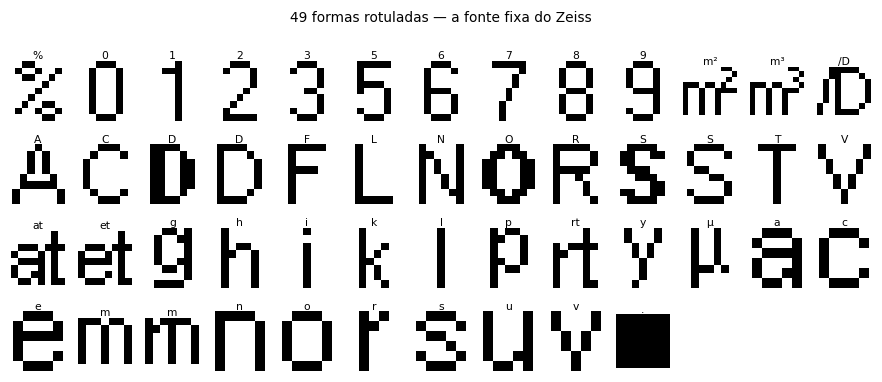

In [6]:
# Mostra o banco inteiro, ordenado por altura do glifo. Serve para auditar a
# rotulacao a olho: sao bitmaps de poucos pixels, todos legiveis.
formas = sorted(BANCO.items(), key=lambda kv: (-kv[0][0][0], kv[1]))
K = 13; L = (len(formas) + K - 1) // K
fig, axes = plt.subplots(L, K, figsize=(K * 0.62, L * 0.85))
for ax in axes.ravel(): ax.axis("off")
for ax, ((sh, b), lab) in zip(axes.ravel(), formas):
    ax.imshow(~np.frombuffer(b, dtype=bool).reshape(sh), cmap="gray", vmin=0, vmax=1)
    ax.set_title(lab, fontsize=7, pad=1.5)
fig.suptitle(f"{len(formas)} formas rotuladas — a fonte fixa do Zeiss", fontsize=9, y=1.0)
plt.tight_layout(); plt.show()

### 8.6 A tabela relida: valor **e** cor

In [7]:
# Monta {campo: {olho: valor, cor, classe}}. O nome do campo sai da coluna 0 da
# propria linha, tambem lido por casamento de padroes.
TABELA = {}
for (r, c), (gs, cor) in sorted(CELS.items()):
    if r == 0 or c == 0: continue
    campo = ler(CELS[(r, 0)][0], BANCO)
    for olho in (["OD", "OS"] if c == 9 else [{1: "OD", 2: "OS"}[c]]):
        TABELA.setdefault(campo, {})[olho] = dict(
            texto=ler(gs, BANCO), rgb=tuple(int(v) for v in cor),
            classe=classificar(cor, REF))

# Exibe a tabela com o fundo pintado pela classe lida — deve ficar igual a pagina.
linhas = []
for campo, d in TABELA.items():
    linhas.append(dict(campo=campo,
                       OD=d["OD"]["texto"], classe_OD=PT[d["OD"]["classe"]],
                       OE=d["OS"]["texto"], classe_OE=PT[d["OS"]["classe"]]))
tab_df = pd.DataFrame(linhas)
def pinta(col_texto, col_classe):
    cor = {"normal": "#66ff66", "limítrofe": "#ffff4c", "fora dos limites": "#fe6263",
           "sem comparação normativa": "#d3d3d3", "acima do normal": "#ffffff"}
    return lambda s: [f"background-color: {cor.get(c, '')}"
                      for c in tab_df[col_classe]]
display(tab_df.style.apply(pinta("OD", "classe_OD"), subset=["OD"])
                    .apply(pinta("OE", "classe_OE"), subset=["OE"])
                    .hide(axis="index"))

campo,OD,classe_OD,OE,classe_OE
AverageRNFLThickness,60µm,fora dos limites,52µm,fora dos limites
RNFLSymmetry,67%,limítrofe,67%,limítrofe
RimArea,0.98mm²,normal,0.86mm²,limítrofe
DiscArea,1.73mm²,sem comparação normativa,1.63mm²,sem comparação normativa
AverageC/DRatio,0.65,normal,0.69,limítrofe
VerticalC/DRatio,0.70,limítrofe,0.75,fora dos limites
CupVolume,0.226mm³,normal,0.278mm³,limítrofe


## 9. Leitura dos diagramas de setor

Cada olho tem dois diagramas circulares: quatro **quadrantes** e doze **setores horários**. Os
números ficam fora do círculo, ao redor.

### 9.1 Geometria

O círculo é encontrado pelos pixels saturados — centroide e raio. A tinta preta fora dele são
os números; dígitos vizinhos na mesma faixa vertical e separados por até 3 px formam um
número. O **ângulo** do número em relação ao centro faz duas coisas ao mesmo tempo:

- diz **qual setor** ele rotula, sem depender das linhas divisórias;
- diz **onde amostrar a cor**: em 0,62 do raio, no mesmo ângulo.

Assim número e cor são emparelhados pela geometria, não por uma tabela de posições.

### 9.2 Um banco de dígitos que a página completa sozinha

Os dígitos dos diagramas têm **8 px de altura**, contra 9 px na tabela — desenho condensado,
mesma fonte. Seis dos dez saem automaticamente: são o dígito da tabela com **uma linha
removida**, o que se verifica exaustivamente. Os outros quatro (`0`, `1`, `4`, `5`) são
redesenhos genuínos e ficam rotulados explicitamente, como bitmaps de 8×5 — legíveis a olho
nu, portanto auditáveis.

### 9.3 Mapeamento anatômico, e o espelhamento entre os olhos

Ângulo vira nome de quadrante: superior, inferior, e — no eixo horizontal — **nasal ou
temporal conforme o olho**. Em OD o lado nasal está à direita da figura; em OE, à esquerda.
Errar essa inversão trocaria a nomenclatura de todos os setores. Os setores horários seguem a
mesma lógica: em OD as horas correm no sentido horário a partir do topo, em OE no
anti-horário.

In [8]:
# Os digitos dos diagramas sao 1 px mais baixos que os da tabela. Seis dos dez sao o
# digito da tabela com uma linha removida (resolvidos automaticamente em propagar()).
# Estes quatro sao desenhos proprios e ficam escritos aqui, como bitmap.
DIGITOS_CONDENSADOS = {   # os 4 desenhos 8x5 que nao derivam dos 9x5 por remocao de linha
    "...#...##..#.#..#.#.#..#.#####...#....#.": "4",
    "..#.###.#..#..#..#..#..#":                 "1",
    ".###.#...##...##...##...##...##...#.###.": "0",
    ".####.#...#....####.....#....##...#.###.": "5"}

def bits(m) -> str:
    return "".join("#" if v else "." for v in m.reshape(-1))

def numeros(diag: np.ndarray):
    """Agrupa a tinta fora do circulo em numeros; devolve tambem centro e raio."""
    # O circulo colorido da o centro e o raio; a tinta preta fora dele sao os numeros.
    t   = diag.max(axis=2) < TINTA
    sat = (diag.max(axis=2) - diag.min(axis=2)) > SAT
    ys, xs = np.nonzero(sat); cy, cx = ys.mean(), xs.mean()
    rad = float(np.hypot(ys - cy, xs - cx).max())
    yy, xx = np.mgrid[:t.shape[0], :t.shape[1]]
    lb, _ = ndi.label(t & (np.hypot(yy - cy, xx - cx) > rad + 2), structure=np.ones((3, 3)))
    gl = []
    for k, sl in enumerate(ndi.find_objects(lb), 1):
        m = lb[sl] == k
        gl.append(dict(y=sl[0].start, x=sl[1].start, h=m.shape[0], w=m.shape[1], m=m))
    gl.sort(key=lambda g: (g["y"], g["x"]))
    # Digitos na mesma altura e quase encostados formam um numero ('7' + '4' = 74).
    grupos = [[gl[0]]]
    for g in gl[1:]:
        p = grupos[-1][-1]
        if abs(g["y"] - p["y"]) <= 2 and 0 <= g["x"] - (p["x"] + p["w"]) <= 3:
            grupos[-1].append(g)
        else: grupos.append([g])
    return grupos, cy, cx, rad

def propagar(banco_tabela: dict, formas: dict):
    """Digito de 8 px = digito de 9 px da tabela com uma linha removida."""
    tab = {l: np.frombuffer(b, dtype=bool).reshape(s)
           for (s, b), l in banco_tabela.items() if l.isdigit()}
    # Para cada forma nova, testa se alguma linha removida de um digito da tabela
    # reproduz exatamente o bitmap. Se so um digito serve, o rotulo e esse.
    novo, herdados = {}, 0
    for k, m in formas.items():
        cand = {d for d, t in tab.items() if t.shape[1] == m.shape[1] and
                any(np.array_equal(np.delete(t, i, axis=0), m) for i in range(t.shape[0]))}
        if len(cand) == 1: novo[k] = cand.pop(); herdados += 1
    for k in [k for k in formas if k not in novo]:
        d = DIGITOS_CONDENSADOS.get(bits(formas[k]))
        if d: novo[k] = d
    return novo, herdados

def ler_setores(diag: np.ndarray, banco: dict) -> list[dict]:
    grupos, cy, cx, rad = numeros(diag)
    out = []
    for g in grupos:
        s = "".join(banco.get((d["m"].shape, d["m"].tobytes()), "?") for d in g)
        gy = np.mean([d["y"] + d["h"] / 2 for d in g])
        gx = np.mean([d["x"] + d["w"] / 2 for d in g])
        # O angulo do numero faz duas coisas: diz que setor ele rotula e onde amostrar a cor.
        th = float(np.degrees(np.arctan2(-(gy - cy), gx - cx)) % 360)
        # Amostra a 75% do raio, no mesmo angulo — dentro do setor correspondente e
        # longe do centro, onde ficam as letras S/N/I/T e o cruzamento dos divisores.
        py = int(round(cy - .75 * rad * np.sin(np.radians(th))))
        px = int(round(cx + .75 * rad * np.cos(np.radians(th))))
        # Um pixel so nao basta: linhas divisorias sao pretas e podem cair na amostra.
        # Pega uma janela 7x7 e usa a mediana apenas dos pixels coloridos.
        jan = diag[max(0, py - 3):py + 4, max(0, px - 3):px + 4].reshape(-1, 3)
        col = jan[(jan.max(axis=1) - jan.min(axis=1)) > SAT]
        rgb = np.median(col if len(col) else jan, axis=0)
        out.append(dict(valor=int(s) if s.isdigit() else None, texto=s, angulo=th,
                        rgb=tuple(int(v) for v in rgb)))
    return out

def anatomia(th: float, olho: str) -> str:
    """Angulo na figura -> quadrante anatomico. Em OE o eixo nasal-temporal inverte."""
    # Superior e inferior valem para os dois olhos; nasal e temporal trocam de lado,
    # porque OD e OE sao espelhados.
    if 45 <= th < 135:  return "superior"
    if 225 <= th < 315: return "inferior"
    direita = th < 45 or th >= 315
    return ("nasal" if direita else "temporal") if olho == "OD" \
      else ("temporal" if direita else "nasal")

# Em OD as horas correm no sentido horario a partir do topo; em OE, ao contrario.
def hora_do_angulo(th: float, olho: str) -> int:
    h = round(((90 - th) if olho == "OD" else (th - 90)) / 30) % 12
    return 12 if h == 0 else h

# Junta as formas dos quatro diagramas antes de rotular.
FORMAS = {}
for grupo in ("quad", "hora"):
    for olho in ("OD", "OS"):
        for d in [d for g in numeros(IMGS[PAPEL[grupo][olho]]["img"])[0] for d in g]:
            FORMAS[(d["m"].shape, d["m"].tobytes())] = d["m"]
BDIG, herdados = propagar(BANCO, FORMAS)
print(f"{len(FORMAS)} formas de dígito nos diagramas: {herdados} herdadas da tabela por "
      f"remoção de linha, {len(FORMAS) - herdados} rotuladas explicitamente")

# Le os quadrantes e os horarios dos dois olhos, ja com o nome anatomico.
SETORES = {}
for olho in ("OD", "OS"):
    q  = ler_setores(IMGS[PAPEL["quad"][olho]]["img"], BDIG)
    hh = ler_setores(IMGS[PAPEL["hora"][olho]]["img"], BDIG)
    SETORES[olho] = dict(
        quadrantes={anatomia(s["angulo"], olho): dict(
            valor=s["valor"], classe=classificar(s["rgb"], REF), rgb=s["rgb"]) for s in q},
        horarios={hora_do_angulo(s["angulo"], olho): dict(
            valor=s["valor"], classe=classificar(s["rgb"], REF), rgb=s["rgb"],
            quadrante=anatomia(s["angulo"], olho)) for s in hh})

quad_df = pd.DataFrame([{"olho": {"OD": "OD", "OS": "OE"}[o], **{
    q: f"{SETORES[o]['quadrantes'][q]['valor']} µm ({PT[SETORES[o]['quadrantes'][q]['classe']]})"
    for q in ("superior", "nasal", "inferior", "temporal")}} for o in ("OD", "OS")])
hora_df = pd.DataFrame([{"olho": {"OD": "OD", "OS": "OE"}[o],
                         **{f"{h}h": SETORES[o]["horarios"][h]["valor"] for h in range(1, 13)}}
                        for o in ("OD", "OS")])
display(quad_df.style.hide(axis="index"))
display(hora_df.style.hide(axis="index"))

10 formas de dígito nos diagramas: 6 herdadas da tabela por remoção de linha, 4 rotuladas explicitamente


olho,superior,nasal,inferior,temporal
OD,74 µm (fora dos limites),60 µm (normal),66 µm (fora dos limites),41 µm (limítrofe)
OE,60 µm (fora dos limites),58 µm (normal),62 µm (fora dos limites),29 µm (fora dos limites)


olho,1h,2h,3h,4h,5h,6h,7h,8h,9h,10h,11h,12h
OD,67,67,60,52,54,66,78,49,32,44,63,93
OE,57,63,53,57,50,79,55,28,27,32,37,85


### 9.4 Conferência visual: número, ângulo e cor amostrada

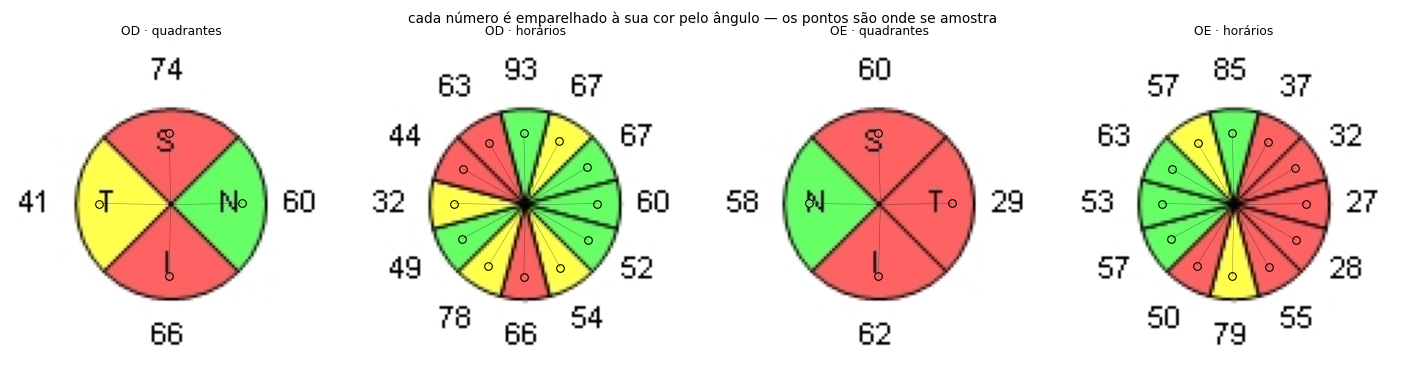

In [9]:
# Cada ponto e onde a cor foi amostrada, pintado com a cor que saiu de la.
# Se a geometria estivesse errada, os pontos cairiam fora dos setores.
fig, axes = plt.subplots(1, 4, figsize=(13, 3.4))
for ax, (olho, grupo) in zip(axes, [("OD", "quad"), ("OD", "hora"),
                                    ("OS", "quad"), ("OS", "hora")]):
    im = IMGS[PAPEL[grupo][olho]]["img"]
    grupos, cy, cx, rad = numeros(im)
    ax.imshow(im.astype(np.uint8))
    for s in ler_setores(im, BDIG):
        th = np.radians(s["angulo"])
        px, py = cx + .75 * rad * np.cos(th), cy - .75 * rad * np.sin(th)
        ax.plot(px, py, "o", ms=5, mfc=np.array(s["rgb"]) / 255, mec="k", mew=.7)
        ax.plot([cx, px], [cy, py], "k-", lw=.3, alpha=.5)
    ax.set_title(f"{ 'OD' if olho=='OD' else 'OE'} · "
                 f"{'quadrantes' if grupo=='quad' else 'horários'}", fontsize=8)
    ax.axis("off")
fig.suptitle("cada número é emparelhado à sua cor pelo ângulo — os pontos são onde se amostra",
             fontsize=9)
plt.tight_layout(); plt.show()

## 10. Escavação horizontal: o número que não está na página

O laudo-modelo pede a escavação nos **dois eixos** — "0,59 × 0,65". O Cirrus imprime a
**vertical** e a **média**; a horizontal não aparece em lugar nenhum. É o único campo que
exige medir algo na imagem em vez de ler.

### 10.1 O que os tomogramas já trazem

Os quatro tomogramas extraídos (horizontal e vertical, por olho) vêm com a **membrana
limitante interna traçada em vermelho pelo próprio aparelho**, e com **dois marcadores
circulares** sobre a margem do disco — a abertura da membrana de Bruch, que define o disco.

Isso muda o problema. Não é preciso segmentar a camada: ela está desenhada, e re-segmentá-la
seria justamente "refazer o que o exame já mostra". O que falta é a **geometria** — e é isso
que esta seção calcula.

O contorno sai por chave de cor: o vermelho do traçado é saturado e não se confunde com o
extremo quente da paleta de falsa cor, que tem verde alto. Os marcadores são detectados como
as colunas onde a marca é mais espessa que a mediana.

### 10.2 Por que a razão, e não o valor absoluto

Medir C/D absoluto num único B-scan não reproduz o valor do aparelho, que vem do volume 3D
inteiro: o plano de referência do Cirrus não é recuperável a partir da figura, e o resultado
fica muito sensível a onde se coloca esse plano. A célula seguinte mostra essa sensibilidade
explicitamente.

O que **é** estável é a **anisotropia** — a razão entre o que se mede no eixo horizontal e no
vertical, na mesma imagem e com o mesmo plano. Erros de definição do plano afetam os dois
eixos na mesma direção e se cancelam em boa parte. A estimativa final é:

$$\text{C/D horizontal} \;=\; \underbrace{\text{C/D vertical impressa}}_{\text{do aparelho}}
\;\times\; \underbrace{\frac{\text{largura medida no tomograma horizontal}}
{\text{largura medida no tomograma vertical}}}_{\text{da imagem}}$$

Ou seja: ancora-se no valor validado do equipamento e usa-se a imagem apenas para medir a
**forma** da escavação — que é o que a imagem mede bem e o que o aparelho não informa.

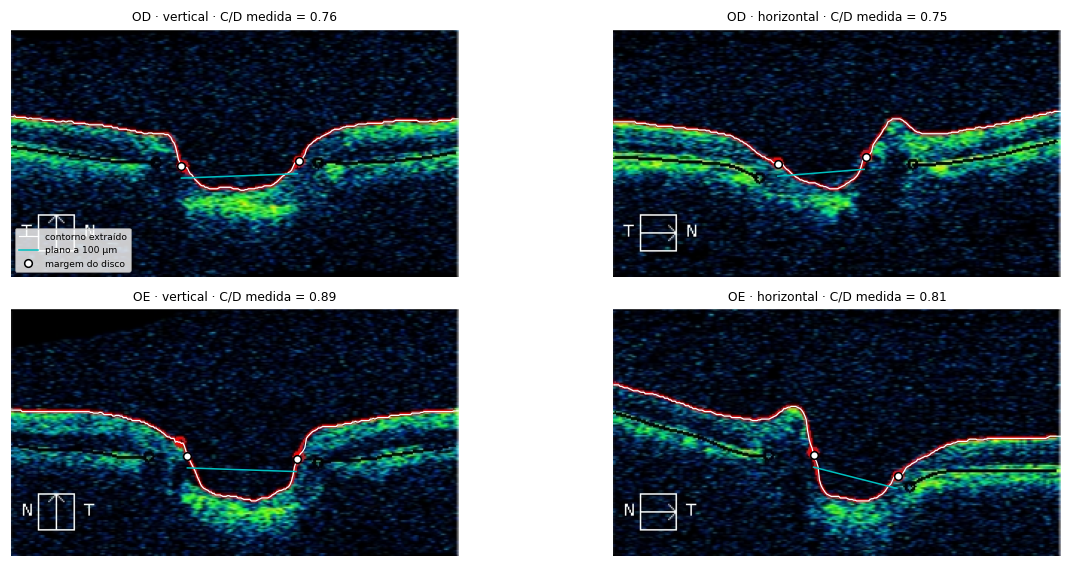

In [10]:
def contorno_ilm(tomo: np.ndarray):
    """Extrai o tracado vermelho da ILM e as duas marcas da margem do disco."""
    # O aparelho ja desenha a membrana limitante interna em vermelho puro. A paleta de
    # falsa cor do tecido tambem chega ao vermelho, mas sempre com verde alto — dai a
    # condicao R muito maior que G e B.
    R, G, B = tomo[..., 0], tomo[..., 1], tomo[..., 2]
    m = (R > 120) & (G < 110) & (B < 110) & (R - np.maximum(G, B) > 60)
    h, w = m.shape
    # Uma altura por coluna: a posicao media dos pixels vermelhos daquela coluna.
    y = np.full(w, np.nan)
    for x in range(w):
        ys = np.nonzero(m[:, x])[0]
        if len(ys): y[x] = ys.mean()
    ok = ~np.isnan(y)
    y = np.interp(np.arange(w), np.nonzero(ok)[0], y[ok])       # fecha falhas de 1-2 px
    # Os dois marcadores da margem do disco sao bolinhas: colunas bem mais espessas
    # que o traco de 1-2 px.
    esp = m.sum(axis=0); lim = np.median(esp[esp > 0]) + 2      # marcas sao mais espessas
    lb, n = ndi.label(esp > lim)
    cs = [np.nonzero(lb == k)[0] for k in range(1, n + 1)]
    marc = [cs[0]]
    for c in cs[1:]:
        if c[0] - marc[-1][-1] < 12: marc[-1] = np.concatenate([marc[-1], c])
        else: marc.append(c)
    return y, [int(np.mean(c)) for c in marc], h, w

def razao_cd(tomo: np.ndarray, plano_um: float = PLANO_UM):
    """Largura da escavacao / largura do disco, num plano paralelo ao plano do disco."""
    y, marc, h, w = contorno_ilm(tomo)
    if len(marc) != 2: return None
    # Plano de referencia: a reta que liga os dois marcadores, deslocada para baixo.
    xL, xR = marc; xx = np.arange(w)
    plano = y[xL] + (y[xR] - y[xL]) * (xx - xL) / (xR - xL) + plano_um / (DEPTH_UM / h)
    # A escavacao e o trecho do contorno que fica abaixo desse plano, entre os marcadores.
    d = np.nonzero((xx >= xL) & (xx <= xR) & (y > plano))[0]
    return (d[-1] - d[0]) / (xR - xL) if len(d) > 1 else 0.0

# Os quatro tomogramas com o contorno extraido, os marcadores e o plano.
fig, axes = plt.subplots(2, 2, figsize=(12, 5.2))
for ax, (olho, eixo) in zip(axes.ravel(), [("OD", "vertical"), ("OD", "horizontal"),
                                           ("OS", "vertical"), ("OS", "horizontal")]):
    im = IMGS[PAPEL["tomo"][(olho, eixo)]]["img"]
    y, marc, h, w = contorno_ilm(im); xL, xR = marc; xx = np.arange(w)
    plano = y[xL] + (y[xR] - y[xL]) * (xx - xL) / (xR - xL) + PLANO_UM / (DEPTH_UM / h)
    ax.imshow(im.astype(np.uint8))
    ax.plot(y, "w-", lw=.8, label="contorno extraído")
    ax.plot(xx[xL:xR], plano[xL:xR], "c-", lw=1.0, label=f"plano a {PLANO_UM:.0f} µm")
    ax.plot([xL, xR], [y[xL], y[xR]], "wo", ms=5, mec="k", label="margem do disco")
    ax.set_title(f"{'OD' if olho=='OD' else 'OE'} · {eixo} · "
                 f"C/D medida = {razao_cd(im):.2f}", fontsize=8)
    ax.axis("off")
axes[0, 0].legend(fontsize=6, loc="lower left")
plt.tight_layout(); plt.show()

### 10.3 Sensibilidade ao plano de referência

A tabela abaixo é o argumento central desta seção. As colunas `medida` oscilam bastante com a
profundidade do plano — o valor absoluto **não** é confiável. As colunas `estimada` mudam
pouco entre 60 e 140 µm, porque o erro se cancela na razão. É por isso que a estimativa se
ancora no valor impresso em vez de tentar reproduzi-lo.

In [11]:
# A razao medida sozinha nao reproduz o valor do aparelho (que vem do volume 3D).
# O que se aproveita e a razao entre os dois eixos, aplicada ao valor vertical impresso.
def escavacao(plano_um=PLANO_UM) -> dict:
    out = {}
    for olho in ("OD", "OS"):
        v = razao_cd(IMGS[PAPEL["tomo"][(olho, "vertical")]]["img"], plano_um)
        hz = razao_cd(IMGS[PAPEL["tomo"][(olho, "horizontal")]]["img"], plano_um)
        imp = float(TABELA["VerticalC/DRatio"][olho]["texto"])
        out[olho] = dict(medido_vertical=v, medido_horizontal=hz, anisotropia=hz / v,
                         impresso_vertical=imp, horizontal_estimada=round(imp * hz / v, 2))
    return out

# Varre a profundidade do plano: as colunas 'medida' oscilam muito, as 'estimada' nao.
sens = []
for p in range(60, 201, 20):
    e = escavacao(p)
    sens.append({"plano (µm)": p,
                 "OD vert medida": round(e["OD"]["medido_vertical"], 2),
                 "OD horiz medida": round(e["OD"]["medido_horizontal"], 2),
                 "OD horiz estimada": e["OD"]["horizontal_estimada"],
                 "OE vert medida": round(e["OS"]["medido_vertical"], 2),
                 "OE horiz medida": round(e["OS"]["medido_horizontal"], 2),
                 "OE horiz estimada": e["OS"]["horizontal_estimada"]})
sens = pd.DataFrame(sens)
display(sens.style.hide(axis="index")
        .background_gradient(cmap="Blues", subset=["OD horiz estimada", "OE horiz estimada"]))

ESCAVACAO = escavacao()
for o in ("OD", "OS"):
    e = ESCAVACAO[o]
    print(f"{'OD' if o=='OD' else 'OE'}: vertical impressa {e['impresso_vertical']:.2f} × "
          f"anisotropia {e['anisotropia']:.3f} → horizontal estimada "
          f"{e['horizontal_estimada']:.2f}")

plano (µm),OD vert medida,OD horiz medida,OD horiz estimada,OE vert medida,OE horiz medida,OE horiz estimada
60,0.860000,0.810000,0.660000,0.930000,0.860000,0.690000
80,0.820000,0.780000,0.660000,0.910000,0.840000,0.700000
100,0.760000,0.750000,0.690000,0.890000,0.810000,0.680000
120,0.720000,0.690000,0.670000,0.880000,0.790000,0.670000
140,0.670000,0.640000,0.670000,0.860000,0.770000,0.670000
160,0.650000,0.560000,0.610000,0.850000,0.750000,0.660000
180,0.570000,0.390000,0.480000,0.820000,0.720000,0.650000
200,0.200000,0.290000,1.000000,0.820000,0.670000,0.610000


OD: vertical impressa 0.70 × anisotropia 0.982 → horizontal estimada 0.69
OE: vertical impressa 0.75 × anisotropia 0.905 → horizontal estimada 0.68


## 11. Relato dos experimentos

Quase toda decisão do pipeline saiu de uma alternativa testada e descartada. Esta seção
reúne o que foi tentado, o que se mediu e o que ficou.

| # | Questão | Alternativas testadas | O que decidiu | Onde |
|---|---|---|---|---|
| E1 | Como separar os caracteres dentro de uma célula? | componentes conexos · projeção vertical | células relidas sem erro | abaixo |
| E2 | Casar os bitmaps por correlação com limiar, ou por igualdade exata? | menor diferença entre formas distintas | abaixo |
| E3 | Fixar as cores no código ou calibrar pela legenda? | margem entre a 1ª e a 2ª referência mais próximas | abaixo |
| E4 | Como rotular os dígitos menores dos diagramas? | propagação por remoção de linha · restrição aritmética · rotulação explícita | quantos dígitos cada via resolve | §9.2 |
| E5 | Medir a escavação em valor absoluto ou em razão? | varredura da profundidade do plano | estabilidade do resultado | §10.3 |
| E6 | Usar um classificador pré-treinado? | sondas de controle no RETFound | resposta a entradas sem conteúdo | §15 |
| E7 | Pode-se recomprimir as imagens? | JPEG q=95 · sem recompressão | estabilidade das medidas | abaixo |

### E4 — o banco de dígitos dos diagramas

Os dígitos dos diagramas são 1 px mais baixos que os da tabela. Três caminhos foram testados
para rotulá-los:

1. **Propagação por remoção de linha** — verificar se o bitmap menor é o da tabela com uma
   linha apagada. Resolve **6 dos 10**; os outros quatro (`0`, `1`, `4`, `5`) são desenhos
   condensados próprios, não versões encurtadas.
2. **Restrição aritmética** — deixar as identidades da §12 escolherem os quatro rótulos
   restantes. Testando as 10⁴ combinações, **5 atribuições diferentes continuam compatíveis**
   com todas as médias da página: a aritmética não distingue, por exemplo, um `0` de um `1`
   numa posição onde a diferença de 1 µm some no arredondamento. **Insuficiente sozinha.**
3. **Rotulação explícita** — escrever os quatro bitmaps 8×5 no código. É o que ficou, e é
   auditável: são desenhos de 40 pixels, legíveis a olho.

O resultado das três vias combinadas passa depois pela §12, que confirma a leitura inteira.

### E7 — recompressão quebra o pipeline

Numa versão anterior deste projeto, as páginas do relatório foram regravadas em JPEG com
qualidade 95 — uma perda visualmente imperceptível. O efeito nas medidas não foi:

- a caixa de um painel deslocou-se 43 px, truncando a retina no recorte;
- a segmentação de uma miniatura degenerou para uma solução paralela sem sentido anatômico;
- o número de painéis aprovados subiu de 2 para 3, com valores implausíveis.

É por isso que a §6 usa `apply_redactions(images=PDF_REDACT_IMAGE_NONE)` e a célula confere
que as 22 imagens embutidas continuam **byte a byte idênticas**. Um pipeline que casa bitmaps
por igualdade exata e segue contornos de 1 px não tolera perda nenhuma.

### E1, E2 e E3, executados

A célula abaixo roda os três sobre esta mesma página.

In [12]:
# Tres experimentos que sustentam as escolhas do pipeline. Todos rodam sobre a mesma
# pagina e imprimem numeros; nada aqui e afirmacao sem medida.

# ---- E1: segmentar caracteres por componentes conexos ou por projecao vertical? ------
def recortar_cc(tinta: np.ndarray) -> list[np.ndarray]:
    """Alternativa a recortar(): cada componente conexo vira um caractere."""
    lb, _ = ndi.label(tinta, structure=np.ones((3, 3)))
    peças = []
    for k, sl in enumerate(ndi.find_objects(lb), 1):
        peças.append((sl[1].start, lb[sl] == k))
    return [m for _, m in sorted(peças, key=lambda t: t[0])]

def tentar(seg):
    """Constroi o banco com uma segmentacao e conta quantas celulas saem exatas."""
    cels, _, _ = celulas(IMGS[PAPEL["tabela"]]["img"], seg)
    try:
        banco = montar_banco(cels)
    except RuntimeError:
        return None, len(REFERENCIA), 0
    exatas = sum(ler(cels[k][0], banco) == v.replace(" ", "")
                 for k, v in REFERENCIA.items())
    return len(banco), len(REFERENCIA), exatas

e1 = []
for nome, seg in [("projeção vertical", recortar), ("componentes conexos", recortar_cc)]:
    formas, total, exatas = tentar(seg)
    e1.append({"segmentação": nome,
               "formas no banco": formas if formas else "—",
               "células relidas sem erro": f"{exatas}/{total}",
               "observação": "—" if formas else "o alinhamento nem converge"})
display(pd.DataFrame(e1).style.hide(axis="index"))
print("E1 — o pingo do 'i' e os três pedaços do '%' viram componentes separados;\n"
      "     a projeção vertical os mantém junto do caractere a que pertencem.\n")

# ---- E2: quao proximas sao as formas distintas entre si? ----------------------------
# Se duas formas diferentes fossem quase iguais, um casamento por correlacao precisaria
# de um limiar delicado. Medimos a menor diferenca entre formas distintas do mesmo tamanho.
por_tam = {}
for (sh, b), lab in BANCO.items():
    por_tam.setdefault(sh, []).append((np.frombuffer(b, dtype=bool).reshape(sh), lab))
pares = []
for sh, itens in por_tam.items():
    for i in range(len(itens)):
        for j in range(i + 1, len(itens)):
            d = int((itens[i][0] != itens[j][0]).sum())
            pares.append((d, sh[0] * sh[1], itens[i][1], itens[j][1]))
pares.sort()
print(f"E2 — {len(pares)} pares de formas distintas de mesmo tamanho.")
print(f"     par mais parecido: {pares[0][2]!r} vs {pares[0][3]!r} — diferem em "
      f"{pares[0][0]} de {pares[0][1]} pixels ({100*pares[0][0]/pares[0][1]:.0f}%)")
print(f"     diferença mediana entre pares: {int(np.median([p[0] for p in pares]))} pixels")
print("     Com igualdade exata não há limiar a escolher: ou o bitmap bate, ou não bate.\n")

# ---- E3: a classificacao de cor tem margem folgada? --------------------------------
# Para cada regiao classificada, distancia a referencia mais proxima (d1) e a segunda (d2).
# Quanto maior d2/d1, mais longe a decisao esta de ser duvidosa.
regioes = [(f"tabela {c} {o}", d["rgb"]) for c, v in TABELA.items() for o, d in v.items()]
regioes += [(f"{o} {g} {k}", v["rgb"]) for o, s in SETORES.items()
            for g, gr in s.items() for k, v in gr.items()]
margens = []
for nome, rgb in regioes:
    d = sorted(float(np.linalg.norm(REF[k] - np.asarray(rgb, float))) for k in REF)
    margens.append({"região": nome, "d1": round(d[0], 1), "d2": round(d[1], 1),
                    "d2/d1": round(d[1] / max(d[0], 1e-6), 1)})
mg = pd.DataFrame(margens)
pior = mg.loc[mg["d2/d1"].idxmin()]
print(f"E3 — {len(mg)} regiões classificadas contra as 5 referências da legenda.")
print(f"     distância mediana à referência escolhida: {mg['d1'].median():.1f} (RGB 0–255)")
print(f"     caso mais apertado: {pior['região']} — d1={pior['d1']}, d2={pior['d2']}, "
      f"razão {pior['d2/d1']}×")
print(f"     margem mínima em todas as regiões: {mg['d2/d1'].min():.1f}× — nenhuma "
      "classificação fica perto do empate.")

segmentação,formas no banco,células relidas sem erro,observação
projeção vertical,49,22/22,—
componentes conexos,—,0/22,o alinhamento nem converge


E1 — o pingo do 'i' e os três pedaços do '%' viram componentes separados;
     a projeção vertical os mantém junto do caractere a que pertencem.

E2 — 119 pares de formas distintas de mesmo tamanho.
     par mais parecido: 'i' vs 'l' — diferem em 1 de 8 pixels (12%)
     diferença mediana entre pares: 15 pixels
     Com igualdade exata não há limiar a escolher: ou o bitmap bate, ou não bate.

E3 — 46 regiões classificadas contra as 5 referências da legenda.
     distância mediana à referência escolhida: 0.0 (RGB 0–255)
     caso mais apertado: OS quadrantes nasal — d1=16.9, d2=143.9, razão 8.5×
     margem mínima em todas as regiões: 8.5× — nenhuma classificação fica perto do empate.


## 12. Validação

Não há gabarito externo: a camada de texto do PDF cobre só o cabeçalho, e os números clínicos
são pixels. Comparar a leitura com a transcrição usada para rotular o banco de formas seria
circular.

Mas a página traz redundância suficiente para se validar sozinha. As mesmas grandezas aparecem
em **três representações independentes**, lidas por caminhos diferentes do código:

| | representação | como é lida |
|---|---|---|
| A | espessura média da RNFL | tabela, dígitos de 9 px, banco da §8 |
| B | quatro quadrantes | diagrama, dígitos de 8 px, banco da §9 |
| C | doze setores horários | diagrama, dígitos de 8 px, banco da §9 |

Se qualquer dígito estivesse errado, as identidades abaixo quebrariam:

1. média dos 4 quadrantes = espessura média impressa (2 checagens, uma por olho);
2. média dos 12 horários = espessura média impressa (2 checagens);
3. cada quadrante = média dos seus 3 horários (8 checagens).

São **12 checagens**, e elas cobrem todas as 38 leituras numéricas da página. A tolerância é
de ±1 µm: os valores impressos estão arredondados a inteiro, então diferenças dessa ordem são
esperadas e não indicam erro.

In [13]:
# A pagina traz a mesma grandeza tres vezes: na tabela, nos quadrantes e nos horarios.
# Se algum digito tivesse sido lido errado, estas identidades nao fechariam.
checagens = []
for olho in ("OD", "OS"):
    o_pt = "OD" if olho == "OD" else "OE"
    media = int(TABELA["AverageRNFLThickness"][olho]["texto"].replace("µm", ""))
    q = {k: v["valor"] for k, v in SETORES[olho]["quadrantes"].items()}
    h = SETORES[olho]["horarios"]
    checagens.append(dict(olho=o_pt, identidade="média dos 4 quadrantes = média impressa",
                          obtido=round(np.mean(list(q.values())), 2), esperado=media))
    checagens.append(dict(olho=o_pt, identidade="média dos 12 horários = média impressa",
                          obtido=round(np.mean([v["valor"] for v in h.values()]), 2),
                          esperado=media))
    # Cada quadrante cobre 3 horarios; a media dos 3 tem de dar o valor do quadrante.
    for nome in ("superior", "nasal", "inferior", "temporal"):
        tres = [v["valor"] for v in h.values() if v["quadrante"] == nome]
        checagens.append(dict(olho=o_pt,
                              identidade=f"quadrante {nome} = média dos seus 3 horários",
                              obtido=round(np.mean(tres), 2), esperado=q[nome]))
val = pd.DataFrame(checagens)
# Tolerancia de 1 µm: os valores impressos ja vem arredondados a inteiro.
val["desvio"] = (val["obtido"] - val["esperado"]).abs().round(2)
val["passa"] = np.where(val["desvio"] <= 1.0, "✓", "✗")
display(val.style.hide(axis="index"))
print(f"\n{(val['passa'] == '✓').sum()}/{len(val)} checagens passam "
      f"(desvio máximo {val['desvio'].max():.2f} µm)")
print(f"formas não reconhecidas em toda a leitura: "
      f"{sum('?' in d[o]['texto'] for d in TABELA.values() for o in d)} na tabela, "
      f"{sum(v['valor'] is None for s in SETORES.values() for g in s.values() for v in g.values())}"
      f" nos diagramas")

olho,identidade,obtido,esperado,desvio,passa
OD,média dos 4 quadrantes = média impressa,60.250000,60,0.250000,✓
OD,média dos 12 horários = média impressa,60.420000,60,0.420000,✓
OD,quadrante superior = média dos seus 3 horários,74.330000,74,0.330000,✓
OD,quadrante nasal = média dos seus 3 horários,59.670000,60,0.330000,✓
OD,quadrante inferior = média dos seus 3 horários,66.000000,66,0.000000,✓
OD,quadrante temporal = média dos seus 3 horários,41.670000,41,0.670000,✓
OE,média dos 4 quadrantes = média impressa,52.250000,52,0.250000,✓
OE,média dos 12 horários = média impressa,51.920000,52,0.080000,✓
OE,quadrante superior = média dos seus 3 horários,59.670000,60,0.330000,✓
OE,quadrante nasal = média dos seus 3 horários,57.670000,58,0.330000,✓



12/12 checagens passam (desvio máximo 0.67 µm)
formas não reconhecidas em toda a leitura: 0 na tabela, 0 nos diagramas


## 13. Achados consolidados

Tudo o que foi lido vira um único objeto. Cada campo carrega **valor, cor amostrada e classe
normativa**, para que a geração do laudo (§14) não precise voltar à imagem e para que qualquer
frase possa ser rastreada até a sua origem.

As regras de anonimização são aplicadas aqui: a paciente é identificada pelo carimbo de tempo
da execução, a data de nascimento é convertida em idade e descartada, e o médico solicitante é
fixo. O `assert` ao final é a garantia de que a data de nascimento não vazou para o objeto.

In [14]:
# A data de nascimento entra aqui e sai como idade; ela nunca vai para o laudo.
def idade(dob: str, exame: str) -> int:
    d = dt.datetime.strptime(dob, "%m/%d/%Y"); e = dt.datetime.strptime(exame, "%m/%d/%Y")
    return e.year - d.year - ((e.month, e.day) < (d.month, d.day))

# Tudo o que foi lido num objeto so, com valor, cor e classe de cada campo.
ss = CAB.get("Signal Strength", [])
ACHADOS = dict(
    paciente=f"Paciente {dt.datetime.now():%Y%m%d-%H%M%S}",   # nunca o nome real
    medico_solicitante=MEDICO,                                 # fixo, nao vem do exame
    idade=idade(CAB["DOB"][0], CAB["Exam Date"][0]),           # DOB derivada e descartada
    sexo={"Female": "feminino", "Male": "masculino"}.get(CAB["Gender"][0], "não informado"),
    equipamento="Cirrus HD-OCT", protocolo="Optic Disc Cube 200x200",
    data_exame=CAB["Exam Date"][0],
    signal_strength={"OD": ss[0], "OS": ss[1]} if len(ss) >= 2 else {},
    legenda={k: [int(v) for v in c] for k, c in REF.items()},
    tabela=TABELA, setores=SETORES, escavacao=ESCAVACAO)

# Garantia de anonimizacao: a data de nascimento nao pode estar no objeto.
assert "DOB" not in json.dumps(ACHADOS) and CAB["DOB"][0] not in json.dumps(ACHADOS)
print(json.dumps({k: v for k, v in ACHADOS.items()
                  if k not in ("tabela", "setores", "legenda")},
                 indent=2, ensure_ascii=False, default=float))
print(f"\ntabela: {len(ACHADOS['tabela'])} campos · "
      f"setores: {sum(len(g) for s in SETORES.values() for g in s.values())} leituras")

{
  "paciente": "Paciente 20260908-204814",
  "medico_solicitante": "Dr. R2D2",
  "idade": 75,
  "sexo": "feminino",
  "equipamento": "Cirrus HD-OCT",
  "protocolo": "Optic Disc Cube 200x200",
  "data_exame": "8/5/2026",
  "signal_strength": {
    "OD": "6/10",
    "OS": "5/10"
  },
  "escavacao": {
    "OD": {
      "medido_vertical": 0.759493670886076,
      "medido_horizontal": 0.7457627118644068,
      "anisotropia": 0.9819209039548022,
      "impresso_vertical": 0.7,
      "horizontal_estimada": 0.69
    },
    "OS": {
      "medido_vertical": 0.8918918918918919,
      "medido_horizontal": 0.8070175438596491,
      "anisotropia": 0.9048378522062732,
      "impresso_vertical": 0.75,
      "horizontal_estimada": 0.68
    }
  }
}

tabela: 7 campos · setores: 32 leituras


## 14. Regras determinísticas e o laudo

Cada regra recebe campos do JSON e devolve uma frase **acompanhada da sua procedência**. Nada
entra no texto sem origem declarada — é isso que separa este laudo de um texto gerado por um
modelo de linguagem, que produziria prosa igualmente fluente sem poder mostrar de onde cada
afirmação veio.

### As regras

**Qualidade** — *Signal Strength* ≥ 7 adequada; 6 no limite; ≤ 5 dispara ressalva obrigatória
sobre a confiabilidade das medidas daquele olho.

**RNFL** — a cor da célula vira o adjetivo: vermelho "abaixo dos limites da normalidade",
amarelo "no limite inferior". Simetria alterada vira afirmação de assimetria.

**Setores** — quadrantes alterados nos territórios **superior e inferior** ganham menção
explícita, porque é ali que passam os feixes arqueados, onde o glaucoma ataca primeiro. Um
setor nasal isolado não tem o mesmo peso. Os setores horários fora dos limites são agrupados
por contiguidade — inclusive na volta de 12h para 1h — e nomeados pelos quadrantes que
atravessam.

**Disco** — escavação vertical do aparelho, horizontal estimada na §10, rima e volume da
escavação quando alterados.

**Síntese** — RNFL média e escavação vertical alteradas **nos dois olhos** configuram a
conclusão de sinais estruturais sugestivos de neuropatia óptica glaucomatosa; o olho com mais
campos vermelhos é apontado como o mais acometido.

**O que não foi avaliado** — declarado explicitamente. Um laudo que cala sobre o que não
examinou é pior que um que declara: GCC não avaliado (o protocolo não cobre a mácula),
escavação horizontal estimada e não medida pelo aparelho, área de disco sem comparação
normativa.

In [15]:
# Cada regra devolve frases no formato {texto, origem}. A origem e o que permite
# auditar o laudo depois: diz de que campo e de que cor a frase saiu.
ALTERADO, GRAVE = {"limitrofe", "fora dos limites"}, "fora dos limites"
OLHO_PT   = {"OD": "OD", "OS": "OE"}
ARQUEADOS = ("superior", "inferior")

def num(v, casas=2): return f"{v:.{casas}f}".replace(".", ",")
def unidade(txt):
    """'0.86mm²' -> '0,86 mm²'"""
    for u in ("mm³", "mm²", "µm", "%"):
        if txt.endswith(u):
            return txt[:-len(u)].replace(".", ",") + ("" if u == "%" else " ") + u
    return txt.replace(".", ",")
def frase(txt, origem): return dict(texto=txt, origem=origem)

# Qualidade do sinal: >= 7 adequada, 6 no limite, <= 5 exige ressalva.
def r_qualidade(a):
    fs, alerta = [], []
    for o, s in a["signal_strength"].items():
        v = int(s.split("/")[0])
        st = "adequada" if v >= 7 else ("no limite inferior do aceitável" if v == 6
                                        else "abaixo do recomendado")
        fs.append(frase(f"Signal Strength {OLHO_PT[o]} {s} — qualidade {st}.",
                        f"cabeçalho: Signal Strength {o}"))
        if v <= 5: alerta.append(OLHO_PT[o])
    if alerta:
        fs.append(frase("A intensidade de sinal em " + " e ".join(alerta) + " está abaixo do "
                        "recomendado (≥ 7/10); as medidas desse olho devem ser interpretadas "
                        "com reserva.", "regra: Signal Strength ≤ 5"))
    return fs

# Espessura media e simetria: a cor da celula vira o adjetivo da frase.
def r_rnfl(a):
    fs = []
    for o in ("OD", "OS"):
        d = a["tabela"]["AverageRNFLThickness"][o]
        adj = {"fora dos limites": "abaixo dos limites da normalidade",
               "limitrofe": "no limite inferior da normalidade",
               "normal": "dentro dos limites da normalidade",
               "acima do normal": "acima do esperado",
               "NA": "sem comparação normativa"}[d["classe"]]
        fs.append(frase(f"Espessura média da RNFL {OLHO_PT[o]}: {unidade(d['texto'])} — {adj}.",
                        f"tabela: Average RNFL Thickness {o}, célula {d['classe']}"))
    s = a["tabela"]["RNFLSymmetry"]["OD"]
    fs.append(frase(
        f"Simetria entre os olhos de {s['texto']}, {PT[s['classe']]}" +
        (" — há assimetria relevante entre OD e OE." if s["classe"] in ALTERADO else "."),
        f"tabela: RNFL Symmetry, célula {s['classe']}"))
    return fs

# Setores. O glaucoma ataca primeiro os feixes arqueados (superior e inferior),
# entao alteracao nesses quadrantes ganha mencao propria.
def r_setores(a):
    fs = []
    for o in ("OD", "OS"):
        q = a["setores"][o]["quadrantes"]; h = a["setores"][o]["horarios"]
        det = ", ".join(f"{k} {q[k]['valor']} µm ({PT[q[k]['classe']]})"
                        for k in ("superior", "nasal", "inferior", "temporal"))
        fs.append(frase(f"Quadrantes {OLHO_PT[o]} — {det}.",
                        f"diagrama de quadrantes {o}: valor e cor de cada setor"))
        arq = [k for k in ARQUEADOS if q[k]["classe"] in ALTERADO]
        if arq:
            fs.append(frase(f"Em {OLHO_PT[o]} o afinamento acomete o(s) quadrante(s) "
                            f"{' e '.join(arq)}, território dos feixes arqueados — "
                            "distribuição característica da lesão glaucomatosa.",
                            f"regra: quadrante arqueado alterado ({', '.join(arq)}) em {o}"))
        elif not any(v["classe"] in ALTERADO for v in q.values()):
            fs.append(frase(f"Nenhum quadrante alterado em {OLHO_PT[o]}.",
                            f"diagrama de quadrantes {o}"))
        # Agrupa horarios vermelhos consecutivos, inclusive na volta de 12h para 1h.
        ruins = sorted(k for k in h if h[k]["classe"] == GRAVE)
        if ruins:
            grupos, atual = [], [ruins[0]]
            for k in ruins[1:]:
                if (k - atual[-1]) % 12 == 1: atual.append(k)
                else: grupos.append(atual); atual = [k]
            grupos.append(atual)
            if len(grupos) > 1 and (grupos[0][0] - grupos[-1][-1]) % 12 == 1:
                grupos[0] = grupos[-1] + grupos[0]; grupos.pop()
            def rotulo(g):
                qs = list(dict.fromkeys(h[k]["quadrante"] for k in g))
                return (f"{g[0]}h–{g[-1]}h" if len(g) > 1 else f"{g[0]}h") + f" ({'/'.join(qs)})"
            fs.append(frase(f"Setores horários fora dos limites em {OLHO_PT[o]}: "
                            + "; ".join(rotulo(g) for g in grupos) + ".",
                            f"diagrama de horários {o}: setores vermelhos agrupados por "
                            "contiguidade"))
    return fs

# Escavacao, rima e volume — a horizontal e a estimada na secao anterior.
def r_disco(a):
    fs = []
    for o in ("OD", "OS"):
        vc, e = a["tabela"]["VerticalC/DRatio"][o], a["escavacao"][o]
        fs.append(frase(
            f"Escavação {OLHO_PT[o]}: vertical {num(float(vc['texto']))} ({PT[vc['classe']]}, "
            f"medida pelo equipamento) × horizontal {num(e['horizontal_estimada'])} "
            "(estimada por processamento do tomograma).",
            f"tabela: Vertical C/D Ratio {o} + tomogramas {o} horizontal e vertical"))
        for campo, rot, extra in [("RimArea", "Área da rima neurorretiniana",
                                   ", compatível com afilamento da rima"),
                                  ("CupVolume", "Volume de escavação", "")]:
            d = a["tabela"][campo][o]
            if d["classe"] in ALTERADO:
                fs.append(frase(f"{rot} {OLHO_PT[o]} de {unidade(d['texto'])} — "
                                f"{PT[d['classe']]}{extra}.",
                                f"tabela: {campo} {o}, célula {d['classe']}"))
    return fs

# A conclusao so aparece se RNFL e escavacao estiverem alteradas nos DOIS olhos.
def r_sintese(a):
    fs = []
    rnfl = {o: a["tabela"]["AverageRNFLThickness"][o]["classe"] for o in ("OD", "OS")}
    esc  = {o: a["tabela"]["VerticalC/DRatio"][o]["classe"]     for o in ("OD", "OS")}
    bil_r = all(v in ALTERADO for v in rnfl.values())
    bil_e = all(v in ALTERADO for v in esc.values())
    if bil_r and bil_e:
        fs.append(frase("O conjunto — redução difusa da espessura da RNFL em ambos os olhos "
                        "associada a escavação vertical aumentada — configura sinais "
                        "estruturais sugestivos de neuropatia óptica glaucomatosa bilateral.",
                        "regra: RNFL média e escavação vertical alteradas nos dois olhos"))
    elif bil_r or bil_e:
        fs.append(frase("Há alteração estrutural bilateral, porém sem a associação completa "
                        "entre afinamento da RNFL e aumento da escavação.",
                        "regra: alteração bilateral parcial"))
    graves = {o: sum(d[o]["classe"] == GRAVE for d in a["tabela"].values())
              for o in ("OD", "OS")}
    if max(graves.values()) > min(graves.values()):
        pior = max(graves, key=graves.get)
        fs.append(frase(f"O acometimento é mais acentuado em {OLHO_PT[pior]}.",
                        f"regra: {graves[pior]} campos 'fora dos limites' em {pior} contra "
                        f"{graves[min(graves, key=graves.get)]} no contralateral"))
    return fs

# Declarar o que nao foi avaliado. Um laudo que cala sobre isso e pior que um que diz.
def r_ausentes(a):
    return [
        frase("Complexo de células ganglionares (GCC) não avaliado: o protocolo Optic Disc "
              "Cube 200x200 não inclui a análise macular.",
              "regra: campo ausente no protocolo"),
        frase("A escavação horizontal não é fornecida pelo equipamento; o valor acima foi "
              "obtido por medição geométrica sobre o tomograma e deve ser tratado como "
              "estimativa.", "regra: campo ausente na página, suprido por processamento"),
        frase("Área de disco sem comparação normativa (cinza na legenda do equipamento): "
              f"OD {unidade(a['tabela']['DiscArea']['OD']['texto'])}, "
              f"OE {unidade(a['tabela']['DiscArea']['OS']['texto'])}.",
              "tabela: Disc Area, célula NA")]

RESSALVAS = [
    "Recomenda-se correlação com a avaliação clínica, a pressão intraocular, a gonioscopia e "
    "a perimetria computadorizada.",
    "Sugiro não analisar estes dados isoladamente: o exame estrutural complementa, mas não "
    "substitui, o exame oftalmológico.",
    "Achados estruturais devem ser acompanhados de forma seriada; a progressão é mais "
    "informativa que qualquer medida isolada."]

# Monta o texto final. As frases ja vem prontas das regras.
def gerar_laudo(a):
    secoes = [("Qualidade do exame", r_qualidade(a)),
              ("Camada de fibras nervosas da retina (RNFL)", r_rnfl(a)),
              ("Análise setorial", r_setores(a)),
              ("Disco óptico e escavação", r_disco(a)),
              ("Interpretação", r_sintese(a)),
              ("Não avaliado neste exame", r_ausentes(a)),
              ("Ressalvas", [frase(r, "texto fixo do modelo de laudo") for r in RESSALVAS])]
    L = ["TOMOGRAFIA DE COERÊNCIA ÓPTICA (OCT)",
         "Nervo óptico e camada de fibras nervosas da retina", "",
         f"Paciente: {a['paciente']}",
         f"Idade: {a['idade']} anos          Sexo: {a['sexo']}",
         "Motivo: Suspeita de glaucoma",
         f"Médico solicitante: {a['medico_solicitante']}",
         f"Equipamento: {a['equipamento']} — protocolo {a['protocolo']}",
         f"Data do exame: {a['data_exame']}", ""]
    for titulo, fs in secoes:
        if not fs: continue
        L += [titulo.upper(), "-" * len(titulo)] + [f"  {f['texto']}" for f in fs] + [""]
    return "\n".join(L), secoes

LAUDO, SECOES = gerar_laudo(ACHADOS)
print(LAUDO)

TOMOGRAFIA DE COERÊNCIA ÓPTICA (OCT)
Nervo óptico e camada de fibras nervosas da retina

Paciente: Paciente 20260908-204814
Idade: 75 anos          Sexo: feminino
Motivo: Suspeita de glaucoma
Médico solicitante: Dr. R2D2
Equipamento: Cirrus HD-OCT — protocolo Optic Disc Cube 200x200
Data do exame: 8/5/2026

QUALIDADE DO EXAME
------------------
  Signal Strength OD 6/10 — qualidade no limite inferior do aceitável.
  Signal Strength OE 5/10 — qualidade abaixo do recomendado.
  A intensidade de sinal em OE está abaixo do recomendado (≥ 7/10); as medidas desse olho devem ser interpretadas com reserva.

CAMADA DE FIBRAS NERVOSAS DA RETINA (RNFL)
------------------------------------------
  Espessura média da RNFL OD: 60 µm — abaixo dos limites da normalidade.
  Espessura média da RNFL OE: 52 µm — abaixo dos limites da normalidade.
  Simetria entre os olhos de 67%, limítrofe — há assimetria relevante entre OD e OE.

ANÁLISE SETORIAL
----------------
  Quadrantes OD — superior 74 µm (fora do

### 14.1 Rastreabilidade

Toda frase do laudo, com o campo e a cor que a produziram. É a tabela que permite auditar o
resultado sem reexecutar nada — e a razão pela qual este método é defensável num contexto
clínico, onde uma afirmação sem procedência não vale.

In [16]:
# Toda frase do laudo com a sua procedencia. Nada entra no texto sem origem declarada.
rastro = pd.DataFrame([{"seção": t, "frase": f["texto"], "origem": f["origem"]}
                       for t, fs in SECOES for f in fs])
display(rastro.style.hide(axis="index").set_properties(**{"text-align": "left"}))
print(f"{len(rastro)} frases; {rastro['origem'].str.startswith('regra').sum()} vêm de regras "
      f"de interpretação, {(~rastro['origem'].str.startswith('regra')).sum()} de leitura "
      f"direta da página ou de texto fixo.")

seção,frase,origem
Qualidade do exame,Signal Strength OD 6/10 — qualidade no limite inferior do aceitável.,cabeçalho: Signal Strength OD
Qualidade do exame,Signal Strength OE 5/10 — qualidade abaixo do recomendado.,cabeçalho: Signal Strength OS
Qualidade do exame,A intensidade de sinal em OE está abaixo do recomendado (≥ 7/10); as medidas desse olho devem ser interpretadas com reserva.,regra: Signal Strength ≤ 5
Camada de fibras nervosas da retina (RNFL),Espessura média da RNFL OD: 60 µm — abaixo dos limites da normalidade.,"tabela: Average RNFL Thickness OD, célula fora dos limites"
Camada de fibras nervosas da retina (RNFL),Espessura média da RNFL OE: 52 µm — abaixo dos limites da normalidade.,"tabela: Average RNFL Thickness OS, célula fora dos limites"
Camada de fibras nervosas da retina (RNFL),"Simetria entre os olhos de 67%, limítrofe — há assimetria relevante entre OD e OE.","tabela: RNFL Symmetry, célula limitrofe"
Análise setorial,"Quadrantes OD — superior 74 µm (fora dos limites), nasal 60 µm (normal), inferior 66 µm (fora dos limites), temporal 41 µm (limítrofe).",diagrama de quadrantes OD: valor e cor de cada setor
Análise setorial,"Em OD o afinamento acomete o(s) quadrante(s) superior e inferior, território dos feixes arqueados — distribuição característica da lesão glaucomatosa.","regra: quadrante arqueado alterado (superior, inferior) em OD"
Análise setorial,Setores horários fora dos limites em OD: 6h (inferior); 10h–11h (temporal/superior).,diagrama de horários OD: setores vermelhos agrupados por contiguidade
Análise setorial,"Quadrantes OE — superior 60 µm (fora dos limites), nasal 58 µm (normal), inferior 62 µm (fora dos limites), temporal 29 µm (fora dos limites).",diagrama de quadrantes OS: valor e cor de cada setor


24 frases; 7 vêm de regras de interpretação, 17 de leitura direta da página ou de texto fixo.


## 15. Análise dos resultados e conclusões

### O que foi construído

Um pipeline determinístico que vai de um PDF de relatório Zeiss Cirrus a um laudo
interpretativo de glaucoma, sem rede neural, com cada frase rastreável até o campo e a cor que
a originaram. As técnicas são as da disciplina: projeções para segmentar grades, segmentação
de caracteres por projeção vertical, casamento de padrões sobre fonte fixa, classificação em
espaço de cor com referências extraídas da própria imagem, coordenadas polares para associar
rótulo e setor, e chave de cor mais geometria para medir a escavação.

### Os três resultados que sustentam o trabalho

**A fonte do Zeiss é determinística nessa escala.** Os 150 caracteres da tabela colapsam em 49
formas byte a byte idênticas. O casamento de padrões não precisa de limiar de correlação —
vira consulta a dicionário. É um resultado medido, não uma suposição, e é o que torna a
leitura numérica confiável a partir de um bitmap de 274×164.

**A página se valida sozinha.** Sem gabarito externo, as 12 identidades aritméticas da §12
verificam a leitura por três caminhos independentes: a média impressa na tabela, a média dos
quadrantes e a média dos horários, mais a relação entre cada quadrante e seus três horários.
Todas passam com desvio máximo compatível com o arredondamento do próprio relatório.

**A anisotropia é estável onde o valor absoluto não é.** A §10.3 mostra a razão C/D medida
oscilando fortemente com a profundidade do plano de referência, enquanto a estimativa da
escavação horizontal — ancorada no valor vertical impresso — varia pouco na faixa de 60 a
140 µm. Reconhecer qual quantidade a imagem mede bem, e usar o aparelho para o resto, foi o
que tornou esse campo utilizável.

### Limitações

- **Um único exame.** O layout do relatório é fixo para este protocolo e versão de software,
  mas a robustez a outras versões não foi testada. As posições em `por_papel()` são o ponto
  mais frágil nesse sentido.
- **A escavação horizontal é estimativa**, obtida de um único corte, não do volume. Está
  declarada como tal no laudo.
- **A rotulação do banco de formas** depende de uma transcrição manual feita uma vez. Ela é
  auditável — as formas são exibidas na §8.5 — mas não é automática.
- **O protocolo não cobre a mácula**, então não há GCC. O laudo declara a ausência.
- **A profundidade axial de 2 mm** dos tomogramas é uma característica do equipamento
  assumida, não impressa na página. Ela afeta apenas a posição do plano de referência, cujo
  efeito está quantificado na §10.3.
- **O laudo não é um diagnóstico.** É um texto estruturado a partir de achados estruturais,
  para leitura por um profissional. As ressalvas fixas estão no próprio laudo por isso.

### Sobre não usar aprendizado de máquina

Uma versão anterior deste projeto avaliou o classificador RETFound pré-treinado para OCT
(`bitfount/RETFound_MAE_OCT_CNV_DME_DRU`, ViT-L/16). Sondas de controle mostraram que ele
devolvia a mesma classe para qualquer entrada — ruído branco 0,431, cinza uniforme 0,332,
imagem toda branca 0,696 — e a análise dos pesos confirmou o motivo: normas L2 por classe
quase idênticas (0,5121 / 0,5146 / 0,5150 / 0,5106) e vieses próximos de zero, o perfil de uma
camada de classificação **nunca treinada**. Não era erro de carregamento: as chaves do
*checkpoint* correspondiam à configuração usada, e as alternativas públicas ou eram o
codificador MAE puro ou falhavam ao carregar.

O episódio não é apenas justificativa retrospectiva. É a razão de o trabalho ter tomado a
direção determinística: um modelo publicado, com nome respeitável, foi verificado e reprovado.
Aqui, cada afirmação do laudo pode ser apontada de volta a um pixel da página — o que nenhum
classificador opaco ofereceria, mesmo funcionando.

### Extensão natural

Dois caminhos, em ordem de valor:

1. **O relatório *Ganglion Cell OU Analysis*** usa a mesma gramática visual — tabela com grade,
   diagramas setoriais, a mesma legenda de cores, a mesma fonte. Praticamente todo o código
   desta análise se aplica, e ele traz o **GCC**, o campo que falta ao laudo.
2. **Uma camada de redação por modelo de linguagem** sobre o JSON de achados, restrita a usar
   apenas os campos presentes. Produziria prosa mais natural — mas só faz sentido sobre a base
   determinística, que é o que garante que o texto não inventa nada.

---

### Material

Relatório `ONH and RNFL OU Analysis: Optic Disc Cube 200x200`, Cirrus HD-OCT, Carl Zeiss
Meditec, software 7.0.3.19. A codificação normativa por cor e os percentis 95/5/1 estão
impressos na própria página, no bloco "Diversified: Distribution of Normals" que a §7 lê.